In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd

## Exploratory Data analysis

In [47]:
# Loading the data df_bologna_full.parquet

input_path = r"C:\Users\LucasMonero\Documents\data projects\Master Thesis\Weather model\Data\df_bologna_full.parquet"
df = pd.read_parquet(input_path)


In [48]:
# Shape
print("=== SHAPE ===")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

=== SHAPE ===
Rows: 184,079 | Columns: 7


In [49]:
# Data types
print("\n=== DATA TYPES ===")
print(df.dtypes)


=== DATA TYPES ===
time             datetime64[ns]
latitude                float64
longitude               float64
t2m                     float32
SSRD_Wm2                float32
CLEAR_SKY_GHI           float64
GHI                     float64
dtype: object


In [50]:
# Ensure time is sorted and set as index for analysis
df = df.sort_values('time').reset_index(drop=True)

#Check for missing hourly timestamps
expected_range = pd.date_range(start=df['time'].min(), end=df['time'].max(), freq='h')
actual_times   = pd.DatetimeIndex(df['time'])

print("=== HOURLY FREQUENCY CHECK ===")
print(f"Expected hourly steps : {len(expected_range):,}")
print(f"Actual rows           : {len(actual_times):,}")
print(f"Difference            : {len(expected_range) - len(actual_times):,}")


=== HOURLY FREQUENCY CHECK ===
Expected hourly steps : 184,079
Actual rows           : 184,079
Difference            : 0


In [51]:
duplicates = df[df['time'].duplicated(keep=False)]

print("\n=== DUPLICATED TIMESTAMPS ===")
if duplicates.empty:
    print("✅  No duplicated timestamps")
else:
    print(f"⚠️  {df['time'].duplicated().sum():,} duplicate rows found")
    print(duplicates[['time', 't2m', 'GHI']].to_string(index=False))



=== DUPLICATED TIMESTAMPS ===
✅  No duplicated timestamps


In [52]:
time_diffs = df['time'].diff().dropna()
expected_delta = pd.Timedelta(hours=1)
irregular = time_diffs[time_diffs != expected_delta]

print("\n=== TIME STEP CONSISTENCY ===")
if irregular.empty:
    print("✅  All time steps are exactly 1 hour")
else:
    print(f"⚠️  {len(irregular):,} irregular time steps found:")
    print(pd.DataFrame({
        'timestamp'     : df.loc[irregular.index, 'time'].values,
        'prev_timestamp': df.loc[irregular.index - 1, 'time'].values,
        'delta'         : irregular.values
    }).to_string(index=False))


=== TIME STEP CONSISTENCY ===
✅  All time steps are exactly 1 hour


In [53]:
total_rows    = len(df)
missing       = df.isnull().sum()
missing_pct   = (missing / total_rows * 100).round(4)

missing_summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct, 'dtype': df.dtypes})
print("=== MISSING VALUES SUMMARY ===")
print(missing_summary)
print(f"\n{'✅ No missing values' if missing.sum() == 0 else f'⚠️ Total missing cells: {missing.sum():,}'}")


=== MISSING VALUES SUMMARY ===
               missing_count  missing_%           dtype
time                       0     0.0000  datetime64[ns]
latitude                   0     0.0000         float64
longitude                  0     0.0000         float64
t2m                        0     0.0000         float32
SSRD_Wm2                   0     0.0000         float32
CLEAR_SKY_GHI              0     0.0000         float64
GHI                       53     0.0288         float64

⚠️ Total missing cells: 53


In [54]:
# Check the hourly distribution of GHI values missing values
print("\n=== HOURLY MISSING GHI DISTRIBUTION ===")
missing_ghi = df[df['GHI'].isnull()]
if missing_ghi.empty:
    print("✅  No missing GHI values")
else:
    missing_ghi['hour'] = missing_ghi['time'].dt.hour
    hourly_missing = missing_ghi.groupby('hour').size()
    print(hourly_missing.to_string())

# Check the days where GHI is missing
print("\n=== DAILY MISSING GHI DISTRIBUTION ===")
if missing_ghi.empty:
    print("✅  No missing GHI values")
else:
    missing_ghi['date'] = missing_ghi['time'].dt.date
    daily_missing = missing_ghi.groupby('date').size()
    print(daily_missing.to_string())



=== HOURLY MISSING GHI DISTRIBUTION ===
hour
6     1
7     5
8     5
9     5
10    5
11    5
12    5
13    5
14    5
15    5
16    5
17    1
18    1

=== DAILY MISSING GHI DISTRIBUTION ===
date
2005-01-11    10
2005-01-12    10
2006-01-10    10
2006-01-11    10
2006-09-23    13


C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_5912\1672017393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_ghi['hour'] = missing_ghi['time'].dt.hour
C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_5912\1672017393.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_ghi['date'] = missing_ghi['time'].dt.date


Days with missing GHI: 5 → [datetime.date(2005, 1, 11) datetime.date(2005, 1, 12)
 datetime.date(2006, 1, 10) datetime.date(2006, 1, 11)
 datetime.date(2006, 9, 23)]


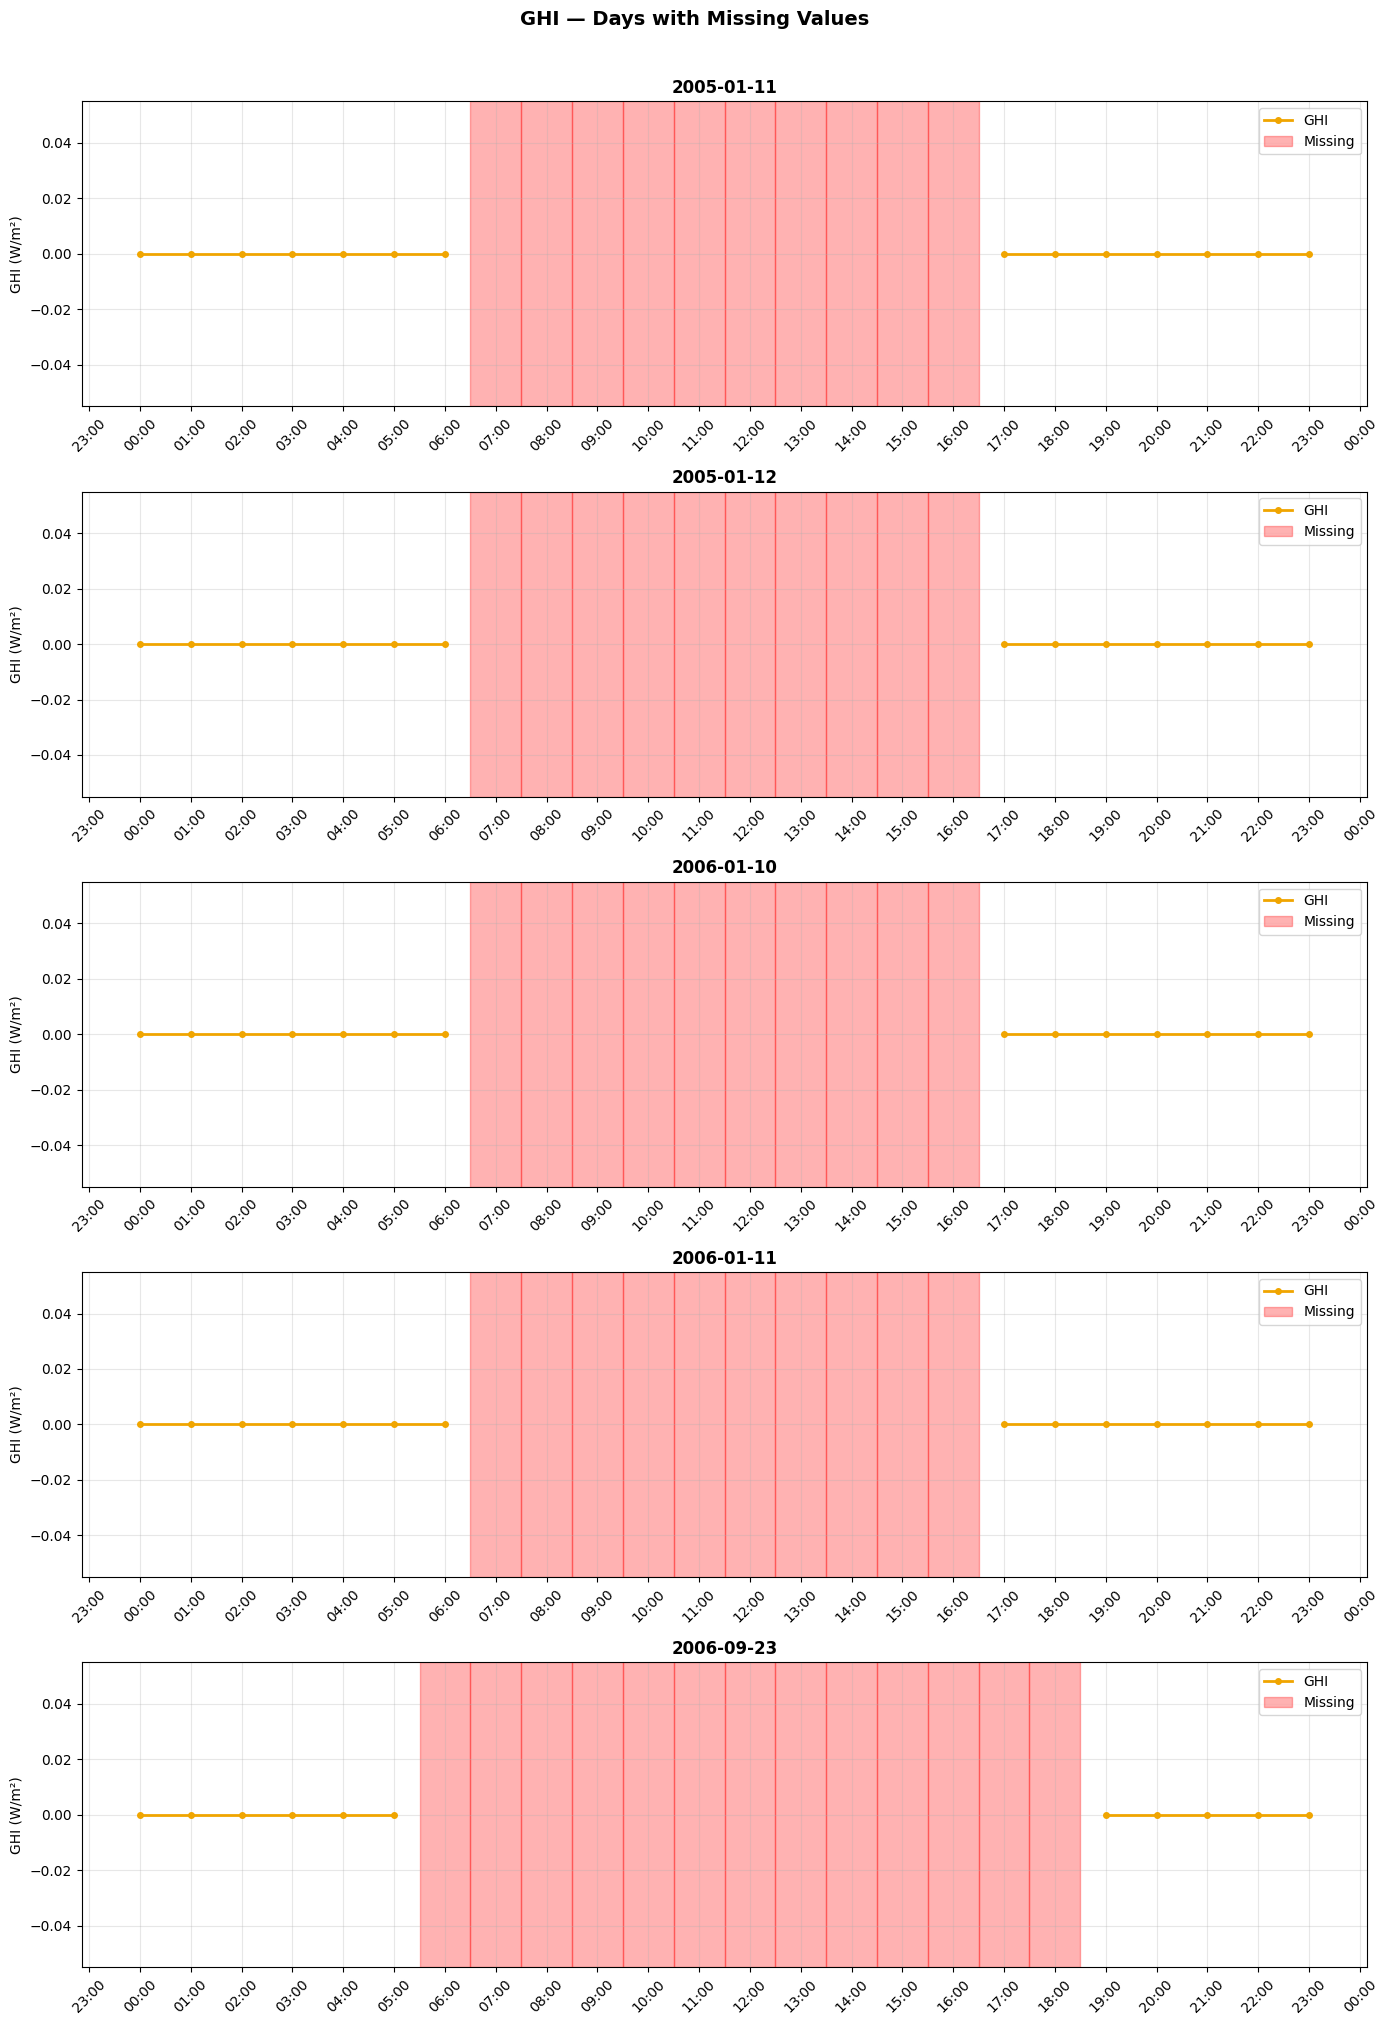

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Get dates with missing GHI ────────────────────────────────────────────────
missing_dates = df[df['GHI'].isnull()]['time'].dt.date.unique()
print(f"Days with missing GHI: {len(missing_dates)} → {missing_dates}")

# ── Filter full days around missing dates ─────────────────────────────────────
df['date'] = df['time'].dt.date
plot_data   = df[df['date'].isin(missing_dates)].copy()

# ── Plot ───────────────────────────────────────────────────────────────────────
n_days = len(missing_dates)
fig, axes = plt.subplots(n_days, 1, figsize=(14, 4 * n_days), sharex=False)
axes = [axes] if n_days == 1 else axes  # handle single day case

for ax, date in zip(axes, missing_dates):
    day_df = plot_data[plot_data['date'] == date]

    ax.plot(day_df['time'], day_df['GHI'], color='#f0a500', lw=2, marker='o', markersize=4, label='GHI')
    
    # Highlight missing hours as red vertical spans
    missing_hours = day_df[day_df['GHI'].isnull()]['time']
    for ts in missing_hours:
        ax.axvspan(ts - pd.Timedelta(minutes=30),
                   ts + pd.Timedelta(minutes=30),
                   color='red', alpha=0.3, label='Missing' if ts == missing_hours.iloc[0] else '')

    ax.set_title(f"{date}", fontsize=12, fontweight='bold')
    ax.set_ylabel("GHI (W/m²)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("GHI — Days with Missing Values", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df = df.drop(columns='date')


In [56]:
df[['t2m', 'SSRD_Wm2', 'GHI', 'CLEAR_SKY_GHI']].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
t2m,286.449982,8.297543,262.209259,279.654663,286.317688,292.988312,309.534119
SSRD_Wm2,158.233871,227.548279,-0.000528,0.000000,6.915555,278.151123,944.195557
GHI,170.191957,254.936004,0.000000,0.000000,7.138676,279.003418,993.442932
CLEAR_SKY_GHI,216.812967,290.272060,0.000000,0.000000,10.403369,408.385818,993.442932


## Statistics and Consistencies

In [57]:
numeric_cols = ['t2m', 'SSRD_Wm2', 'CLEAR_SKY_GHI', 'GHI']

print("=== CORE STATISTICS ===")
stats = df[numeric_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).T
stats['skewness'] = df[numeric_cols].skew()
stats['kurtosis'] = df[numeric_cols].kurt()
stats.round(3)

=== CORE STATISTICS ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skewness,kurtosis
t2m,184079.0,286.450,8.298,262.209,270.589,273.72,279.655,286.318,292.988,300.027,303.669,309.534,0.081,-0.862
SSRD_Wm2,184079.0,158.234,227.548,-0.001,0.000,0.00,0.000,6.916,278.151,666.933,797.319,944.196,1.335,0.586
CLEAR_SKY_GHI,184079.0,216.813,290.272,0.000,0.000,0.00,0.000,10.403,408.386,831.405,921.929,993.443,1.063,-0.265
GHI,184026.0,170.192,254.936,0.000,0.000,0.00,0.000,7.139,279.003,762.844,904.012,993.443,1.454,0.922


In [58]:
print("\n=== SOLAR PHYSICAL BOUNDS CHECK ===")
solar_checks = {
    'SSRD_Wm2'     : (0, 1400),
    'CLEAR_SKY_GHI': (0, 1400),
    'GHI'          : (0, 1400),
}
for col, (lo, hi) in solar_checks.items():
    below = (df[col] < lo).sum()
    above = (df[col] > hi).sum()
    status = '✅' if below == 0 and above == 0 else '⚠️'
    print(f"  {status} {col}: below {lo}: {below:,} | above {hi}: {above:,}")


=== SOLAR PHYSICAL BOUNDS CHECK ===
  ⚠️ SSRD_Wm2: below 0: 2 | above 1400: 0
  ✅ CLEAR_SKY_GHI: below 0: 0 | above 1400: 0
  ✅ GHI: below 0: 0 | above 1400: 0


In [59]:
print("\n=== GHI vs CLEAR_SKY_GHI CONSISTENCY ===")
daytime_df  = df[df['CLEAR_SKY_GHI'] > 0].copy()
overshot    = (daytime_df['GHI'] > daytime_df['CLEAR_SKY_GHI']).sum()
pct         = overshot / len(daytime_df) * 100
print(f"  Hours where GHI > CLEAR_SKY_GHI: {overshot:,} ({pct:.2f}%)")
print(f"  {'✅ Within bounds' if pct < 1 else '⚠️  Possible data issue — GHI exceeding clear-sky envelope'}")



=== GHI vs CLEAR_SKY_GHI CONSISTENCY ===
  Hours where GHI > CLEAR_SKY_GHI: 1 (0.00%)
  ✅ Within bounds


In [60]:
print("\n=== CLEARNESS INDEX (GHI / CLEAR_SKY_GHI) ===")
daytime_df['kt'] = daytime_df['GHI'] / daytime_df['CLEAR_SKY_GHI']
kt_stats         = daytime_df['kt'].describe(percentiles=[.05, .25, .50, .75, .95]).round(3)
print(kt_stats)
out_of_range = ((daytime_df['kt'] < 0) | (daytime_df['kt'] > 1)).sum()
print(f"\n  Values outside [0, 1]: {out_of_range:,} {'✅' if out_of_range == 0 else '⚠️'}")



=== CLEARNESS INDEX (GHI / CLEAR_SKY_GHI) ===
count    99974.000
mean         0.780
std          0.296
min          0.063
5%           0.135
25%          0.604
50%          0.961
75%          1.000
95%          1.000
max          1.003
Name: kt, dtype: float64

  Values outside [0, 1]: 1 ⚠️


In [61]:
threshold = 10  # °C or K change in one hour
df['t2m_diff'] = df['t2m'].diff().abs()

spikes = df[df['t2m_diff'] > threshold][['time', 't2m', 't2m_diff']].copy()
spikes['t2m_prev'] = df.loc[spikes.index - 1, 't2m'].values

print(f"=== TEMPERATURE SPIKES > {threshold} K in 1h ===")
if spikes.empty:
    print("✅  No suspicious temperature spikes found")
else:
    print(f"⚠️  {len(spikes)} spike(s) found:\n")
    print(spikes[['time', 't2m_prev', 't2m', 't2m_diff']].to_string(index=False))

=== TEMPERATURE SPIKES > 10 K in 1h ===
✅  No suspicious temperature spikes found


In [62]:

# Full series (all hours)
df_full    = df.copy()

# Daytime only (GHI > 0)
df_day     = df[df['GHI'] > 0].reset_index(drop=True)

# Clearness index — computed on daytime only
df_day     = df_day.assign(Kt = df_day['GHI'] / df_day['CLEAR_SKY_GHI'])

print("=== SUBSET SIZES ===")
print(f"  Full series : {len(df_full):,} hours")
print(f"  Daytime only: {len(df_day):,} hours  ({len(df_day)/len(df_full)*100:.1f}% of total)")

print("\n=== Kt SANITY CHECK ===")
kt_out = ((df_day['Kt'] < 0) | (df_day['Kt'] > 1)).sum()
print(f"  Kt range   : {df_day['Kt'].min():.4f} → {df_day['Kt'].max():.4f}")
print(f"  Outside [0,1]: {kt_out:,} {'✅' if kt_out == 0 else '⚠️'}")

=== SUBSET SIZES ===
  Full series : 184,079 hours
  Daytime only: 99,974 hours  (54.3% of total)

=== Kt SANITY CHECK ===
  Kt range   : 0.0627 → 1.0031
  Outside [0,1]: 1 ⚠️


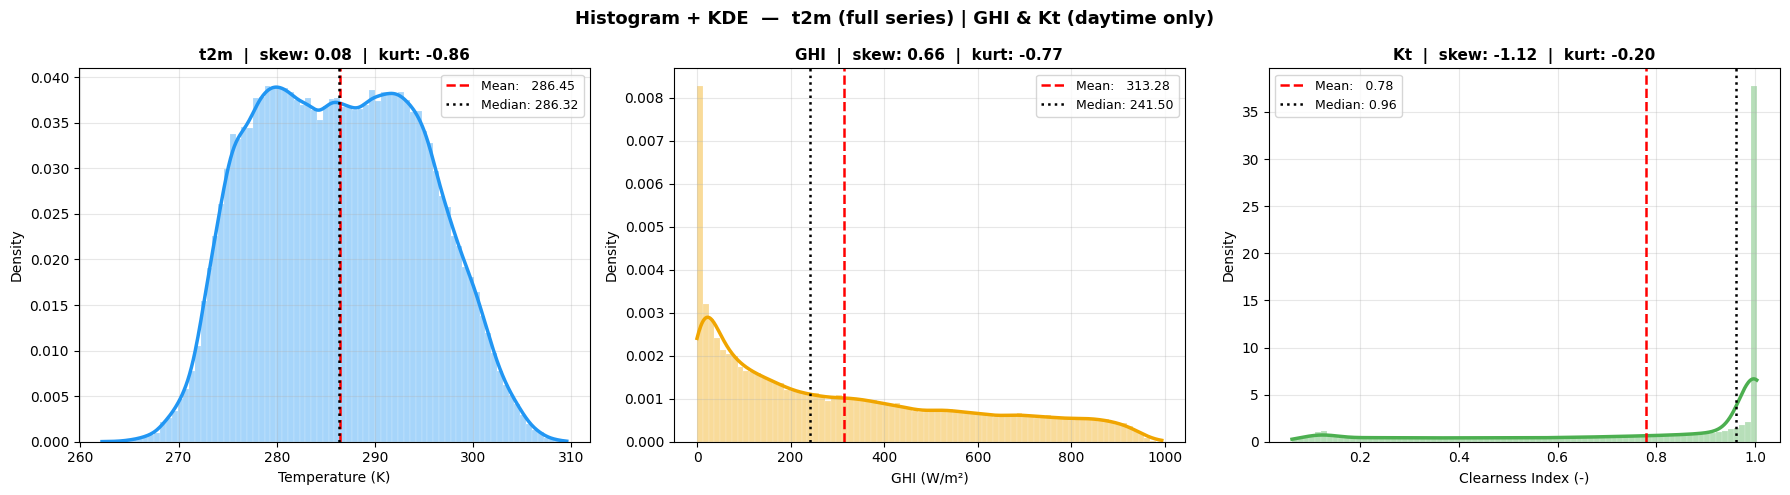

In [63]:
variables = [
    {'col': 't2m',  'data': df_full, 'label': 'Temperature (K)',   'color': '#2196F3', 'bins': 80},
    {'col': 'GHI',  'data': df_day,  'label': 'GHI (W/m²)',        'color': '#f0a500', 'bins': 80},
    {'col': 'Kt',   'data': df_day,  'label': 'Clearness Index (-)', 'color': '#4CAF50', 'bins': 80},
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, variables):
    data   = var['data'][var['col']].dropna()
    color  = var['color']

    # Histogram
    counts, edges, _ = ax.hist(data, bins=var['bins'], color=color, alpha=0.4,
                                edgecolor='white', linewidth=0.3, density=True)

    # KDE
    kde    = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 500)
    ax.plot(x_vals, kde(x_vals), color=color, lw=2.5)

    # Vertical lines for mean and median
    ax.axvline(data.mean(),   color='red',    lw=1.8, linestyle='--', label=f'Mean:   {data.mean():.2f}')
    ax.axvline(data.median(), color='black',  lw=1.8, linestyle=':',  label=f'Median: {data.median():.2f}')

    # Annotations
    ax.set_title(f"{var['col']}  |  skew: {data.skew():.2f}  |  kurt: {data.kurt():.2f}", fontsize=11, fontweight='bold')
    ax.set_xlabel(var['label'])
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Histogram + KDE  —  t2m (full series) | GHI & Kt (daytime only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
print("=== DISTRIBUTION SUMMARY ===")
for var in variables:
    data = var['data'][var['col']].dropna()
    print(f"\n  {var['col']}:")
    print(f"    Mean={data.mean():.3f} | Median={data.median():.3f} | Std={data.std():.3f}")
    print(f"    Skewness={data.skew():.3f} | Kurtosis={data.kurt():.3f}")
    print(f"    Range: [{data.min():.3f}, {data.max():.3f}]")

=== DISTRIBUTION SUMMARY ===

  t2m:
    Mean=286.450 | Median=286.318 | Std=8.298
    Skewness=0.081 | Kurtosis=-0.862
    Range: [262.209, 309.534]

  GHI:
    Mean=313.279 | Median=241.496 | Std=273.510
    Skewness=0.657 | Kurtosis=-0.770
    Range: [0.000, 993.443]

  Kt:
    Mean=0.780 | Median=0.961 | Std=0.296
    Skewness=-1.121 | Kurtosis=-0.198
    Range: [0.063, 1.003]


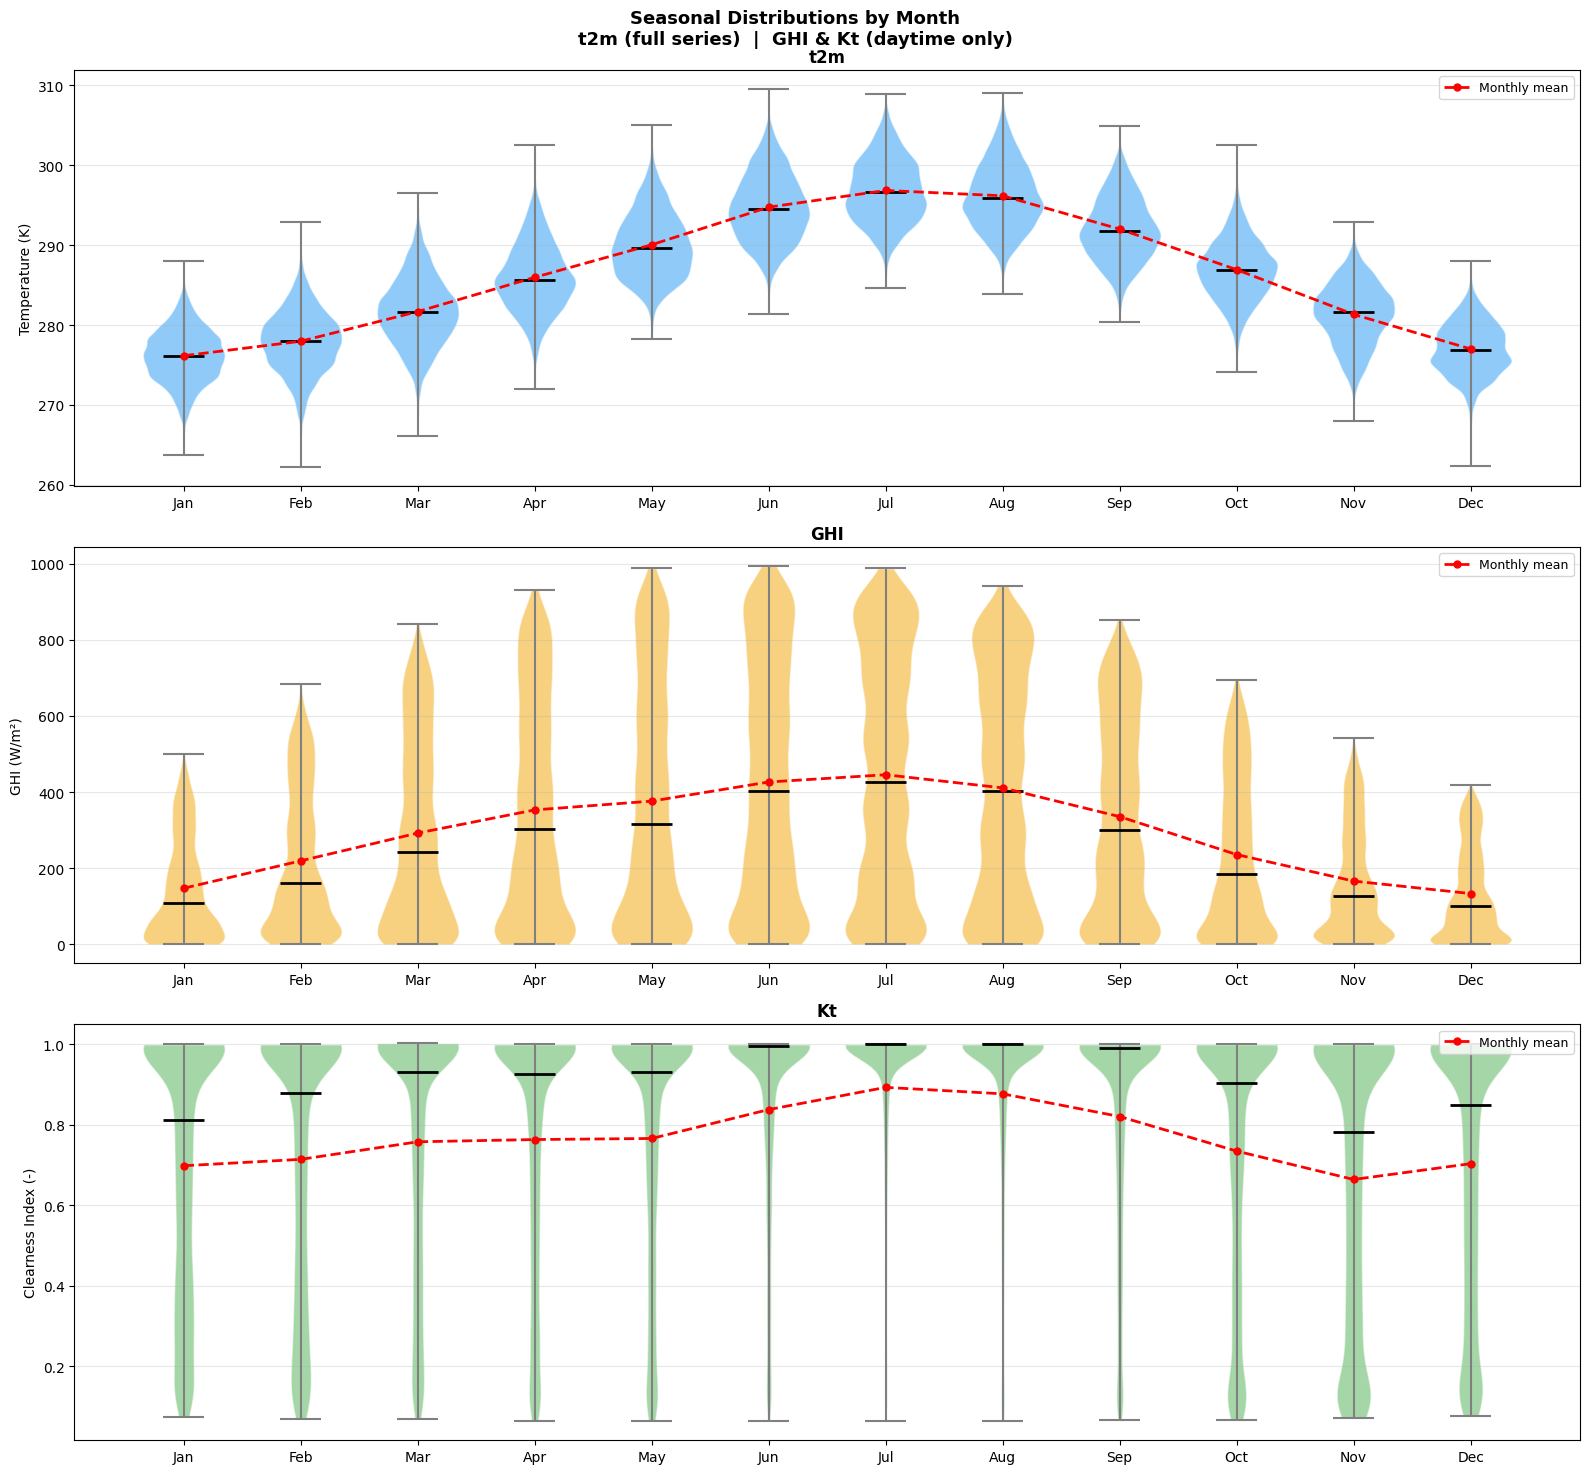

In [65]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

variables = [
    {'col': 't2m', 'data': df_full, 'label': 'Temperature (K)',    'color': '#2196F3'},
    {'col': 'GHI', 'data': df_day,  'label': 'GHI (W/m²)',         'color': '#f0a500'},
    {'col': 'Kt',  'data': df_day,  'label': 'Clearness Index (-)', 'color': '#4CAF50'},
]

fig, axes = plt.subplots(3, 1, figsize=(16, 15))

for ax, var in zip(axes, variables):
    data  = var['data'].assign(month=var['data']['time'].dt.month)
    color = var['color']

    # Build list of arrays per month
    monthly_data = [data.loc[data['month'] == m, var['col']].dropna().values for m in range(1, 13)]

    # Violin plot
    parts = ax.violinplot(monthly_data, positions=range(1, 13),
                          showmedians=True, showextrema=True, widths=0.7)
    # Style violins
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor('white')
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cmaxes'].set_color('grey')
    parts['cmins'].set_color('grey')
    parts['cbars'].set_color('grey')

    # Monthly mean overlay
    monthly_means = [arr.mean() if len(arr) > 0 else np.nan for arr in monthly_data]
    ax.plot(range(1, 13), monthly_means, color='red', lw=2,
            marker='o', markersize=5, linestyle='--', label='Monthly mean')

    ax.set_title(var['col'], fontsize=12, fontweight='bold')
    ax.set_ylabel(var['label'])
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Seasonal Distributions by Month\nt2m (full series)  |  GHI & Kt (daytime only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Analysis of daily statistics

In [66]:

df_daily = (
    df.groupby(df['time'].dt.date)
    .agg(
        t2m_mean      = ('t2m',           'mean'),
        t2m_min       = ('t2m',           'min'),
        t2m_max       = ('t2m',           'max'),
        GHI_sum       = ('GHI',           'sum'),
        GHI_cs_sum    = ('CLEAR_SKY_GHI', 'sum'),
        GHI_var       = ('GHI',           'var'),
    )
    .assign(
        t2m_range  = lambda x: x['t2m_max'] - x['t2m_min'],
        Kt_daily   = lambda x: x['GHI_sum'] / x['GHI_cs_sum']
    )
    .rename_axis('date')
    .reset_index()
)

# Reorder columns
df_daily = df_daily[['date', 't2m_mean', 't2m_min', 't2m_max', 't2m_range',
                      'GHI_sum', 'GHI_cs_sum', 'Kt_daily', 'GHI_var']]

In [67]:
print("=== DAILY STATISTICS DATAFRAME ===")
print(f"Shape: {df_daily.shape}")

df_daily.head(10)

print("\n=== SUMMARY ===")
print(df_daily.describe().round(3))

=== DAILY STATISTICS DATAFRAME ===
Shape: (7670, 9)

=== SUMMARY ===
       t2m_mean   t2m_min   t2m_max  t2m_range   GHI_sum  GHI_cs_sum  \
count  7670.000  7670.000  7670.000   7670.000  7670.000    7670.000   
mean    286.450   282.592   290.497      7.905  4083.409    5203.483   
std       7.791     7.328     8.206      2.801  2445.831    2262.491   
min     266.745   262.209   268.889      0.594     0.000    1535.120   
25%     279.662   276.172   283.463      5.996  1942.053    2936.748   
50%     286.493   282.790   290.419      8.134  3831.266    5302.724   
75%     293.113   288.951   297.450      9.950  6294.920    7408.989   
max     303.109   298.386   309.534     16.579  8898.384    8898.384   

       Kt_daily     GHI_var  
count  7670.000    7670.000  
mean      0.751   56971.084  
std       0.265   45202.145  
min       0.000       0.000  
25%       0.550   15394.557  
50%       0.859   47034.154  
75%       0.983   98333.312  
max       1.000  153893.725  


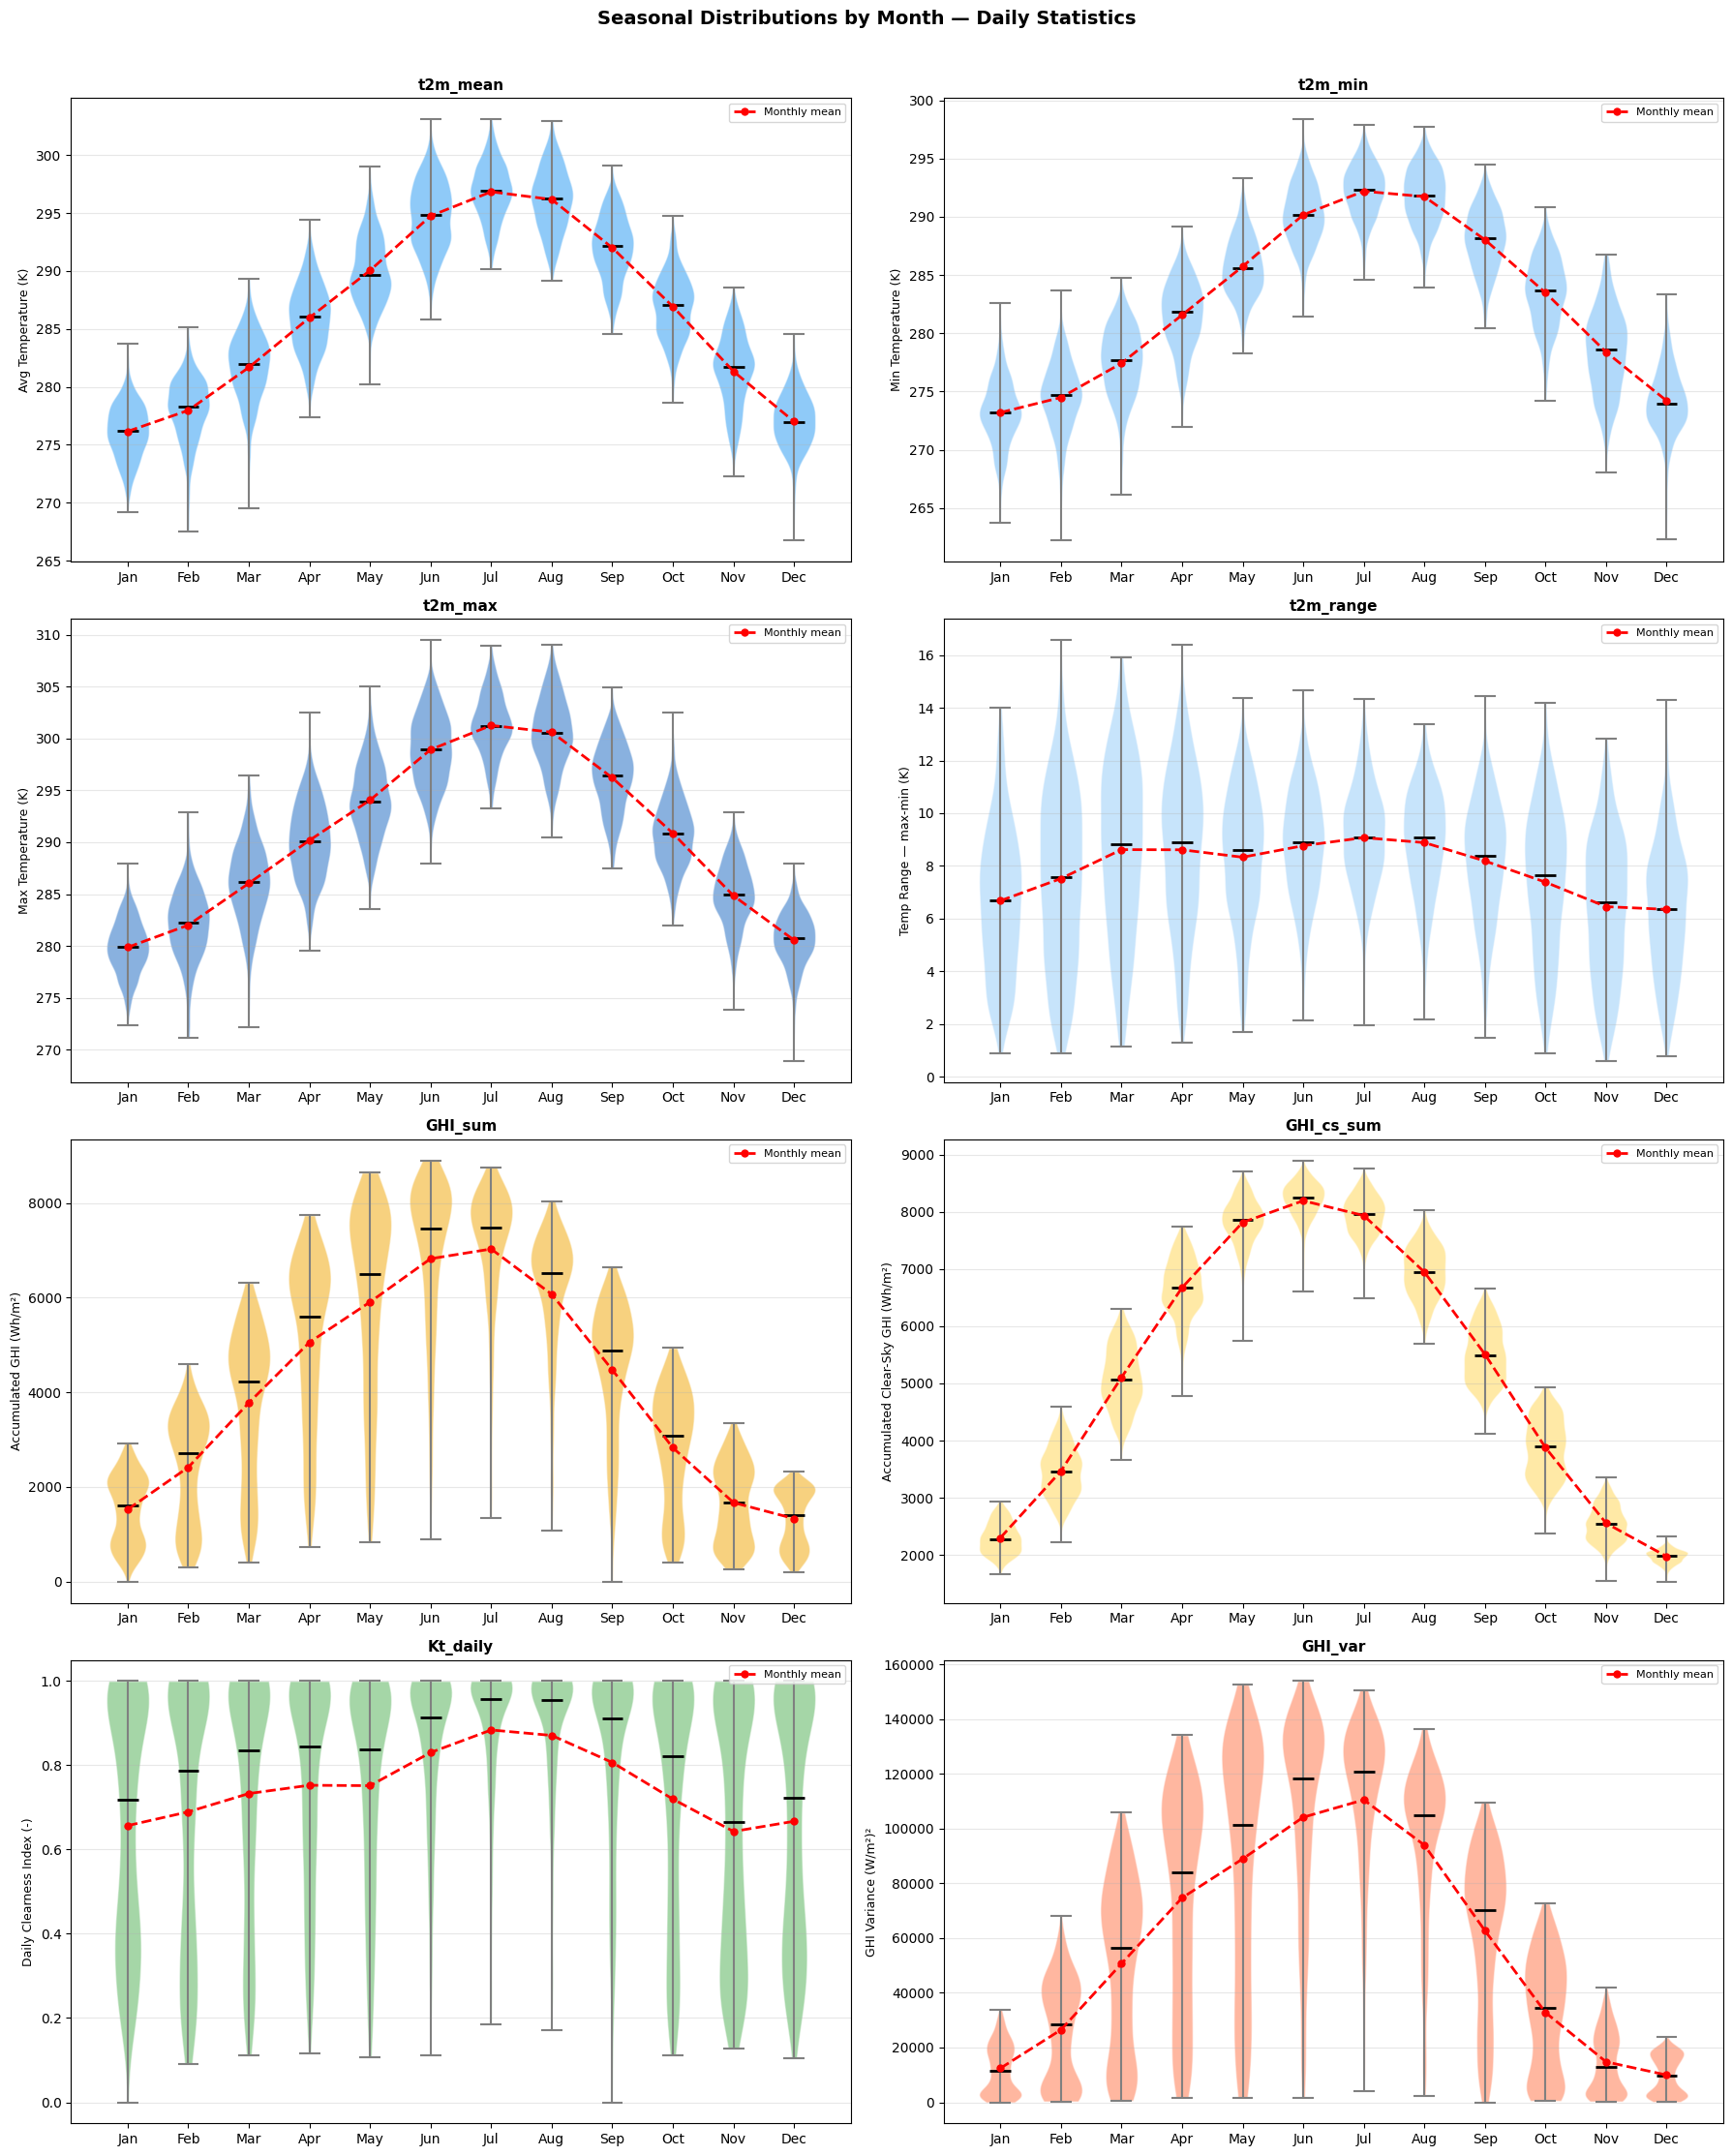

In [68]:

# --- Violin Plots by Month — Daily Statistics ---

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df_daily['month'] = pd.to_datetime(df_daily['date']).dt.month

variables = [
    {'col': 't2m_mean',   'label': 'Avg Temperature (K)'},
    {'col': 't2m_min',    'label': 'Min Temperature (K)'},
    {'col': 't2m_max',    'label': 'Max Temperature (K)'},
    {'col': 't2m_range',  'label': 'Temp Range — max-min (K)'},
    {'col': 'GHI_sum',    'label': 'Accumulated GHI (Wh/m²)'},
    {'col': 'GHI_cs_sum', 'label': 'Accumulated Clear-Sky GHI (Wh/m²)'},
    {'col': 'Kt_daily',   'label': 'Daily Clearness Index (-)'},
    {'col': 'GHI_var',    'label': 'GHI Variance (W/m²)²'},
]

colors = ['#2196F3', '#64B5F6', '#1565C0', '#90CAF9',
          '#f0a500', '#FFD54F', '#4CAF50', '#FF7043']

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()

for ax, var, color in zip(axes, variables, colors):
    monthly_data = [
        df_daily.loc[df_daily['month'] == m, var['col']].dropna().values
        for m in range(1, 13)
    ]

    # Violin plot
    parts = ax.violinplot(monthly_data, positions=range(1, 13),
                          showmedians=True, showextrema=True, widths=0.7)

    # Style violins
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.5)
        pc.set_edgecolor('white')
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cmaxes'].set_color('grey')
    parts['cmins'].set_color('grey')
    parts['cbars'].set_color('grey')

    # Monthly mean overlay
    monthly_means = [arr.mean() if len(arr) > 0 else np.nan for arr in monthly_data]
    ax.plot(range(1, 13), monthly_means, color='red', lw=2,
            marker='o', markersize=5, linestyle='--', label='Monthly mean')

    ax.set_title(var['col'], fontsize=11, fontweight='bold')
    ax.set_ylabel(var['label'], fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Seasonal Distributions by Month — Daily Statistics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [69]:

df_daily['month'] = pd.to_datetime(df_daily['date']).dt.month

kt_monthly_var = (
    df_daily.groupby('month')['Kt_daily']
    .agg(
        count  = 'count',
        mean   = 'mean',
        median = 'median',
        std    = 'std',
        var    = 'var',
    )
    .round(4)
    .rename(index=dict(enumerate(month_labels, 1)))
)

print("=== Kt VARIANCE BY MONTH ===")
print(kt_monthly_var.to_string())

=== Kt VARIANCE BY MONTH ===
       count    mean  median     std     var
month                                       
Jan      651  0.6567  0.7185  0.2890  0.0835
Feb      593  0.6894  0.7870  0.3036  0.0922
Mar      651  0.7328  0.8356  0.2749  0.0756
Apr      630  0.7525  0.8446  0.2511  0.0630
May      651  0.7515  0.8386  0.2458  0.0604
Jun      630  0.8301  0.9126  0.2005  0.0402
Jul      651  0.8837  0.9575  0.1611  0.0260
Aug      651  0.8708  0.9554  0.1820  0.0331
Sep      630  0.8066  0.9114  0.2307  0.0532
Oct      651  0.7196  0.8213  0.2781  0.0773
Nov      630  0.6429  0.6648  0.2902  0.0842
Dec      651  0.6669  0.7221  0.2845  0.0810


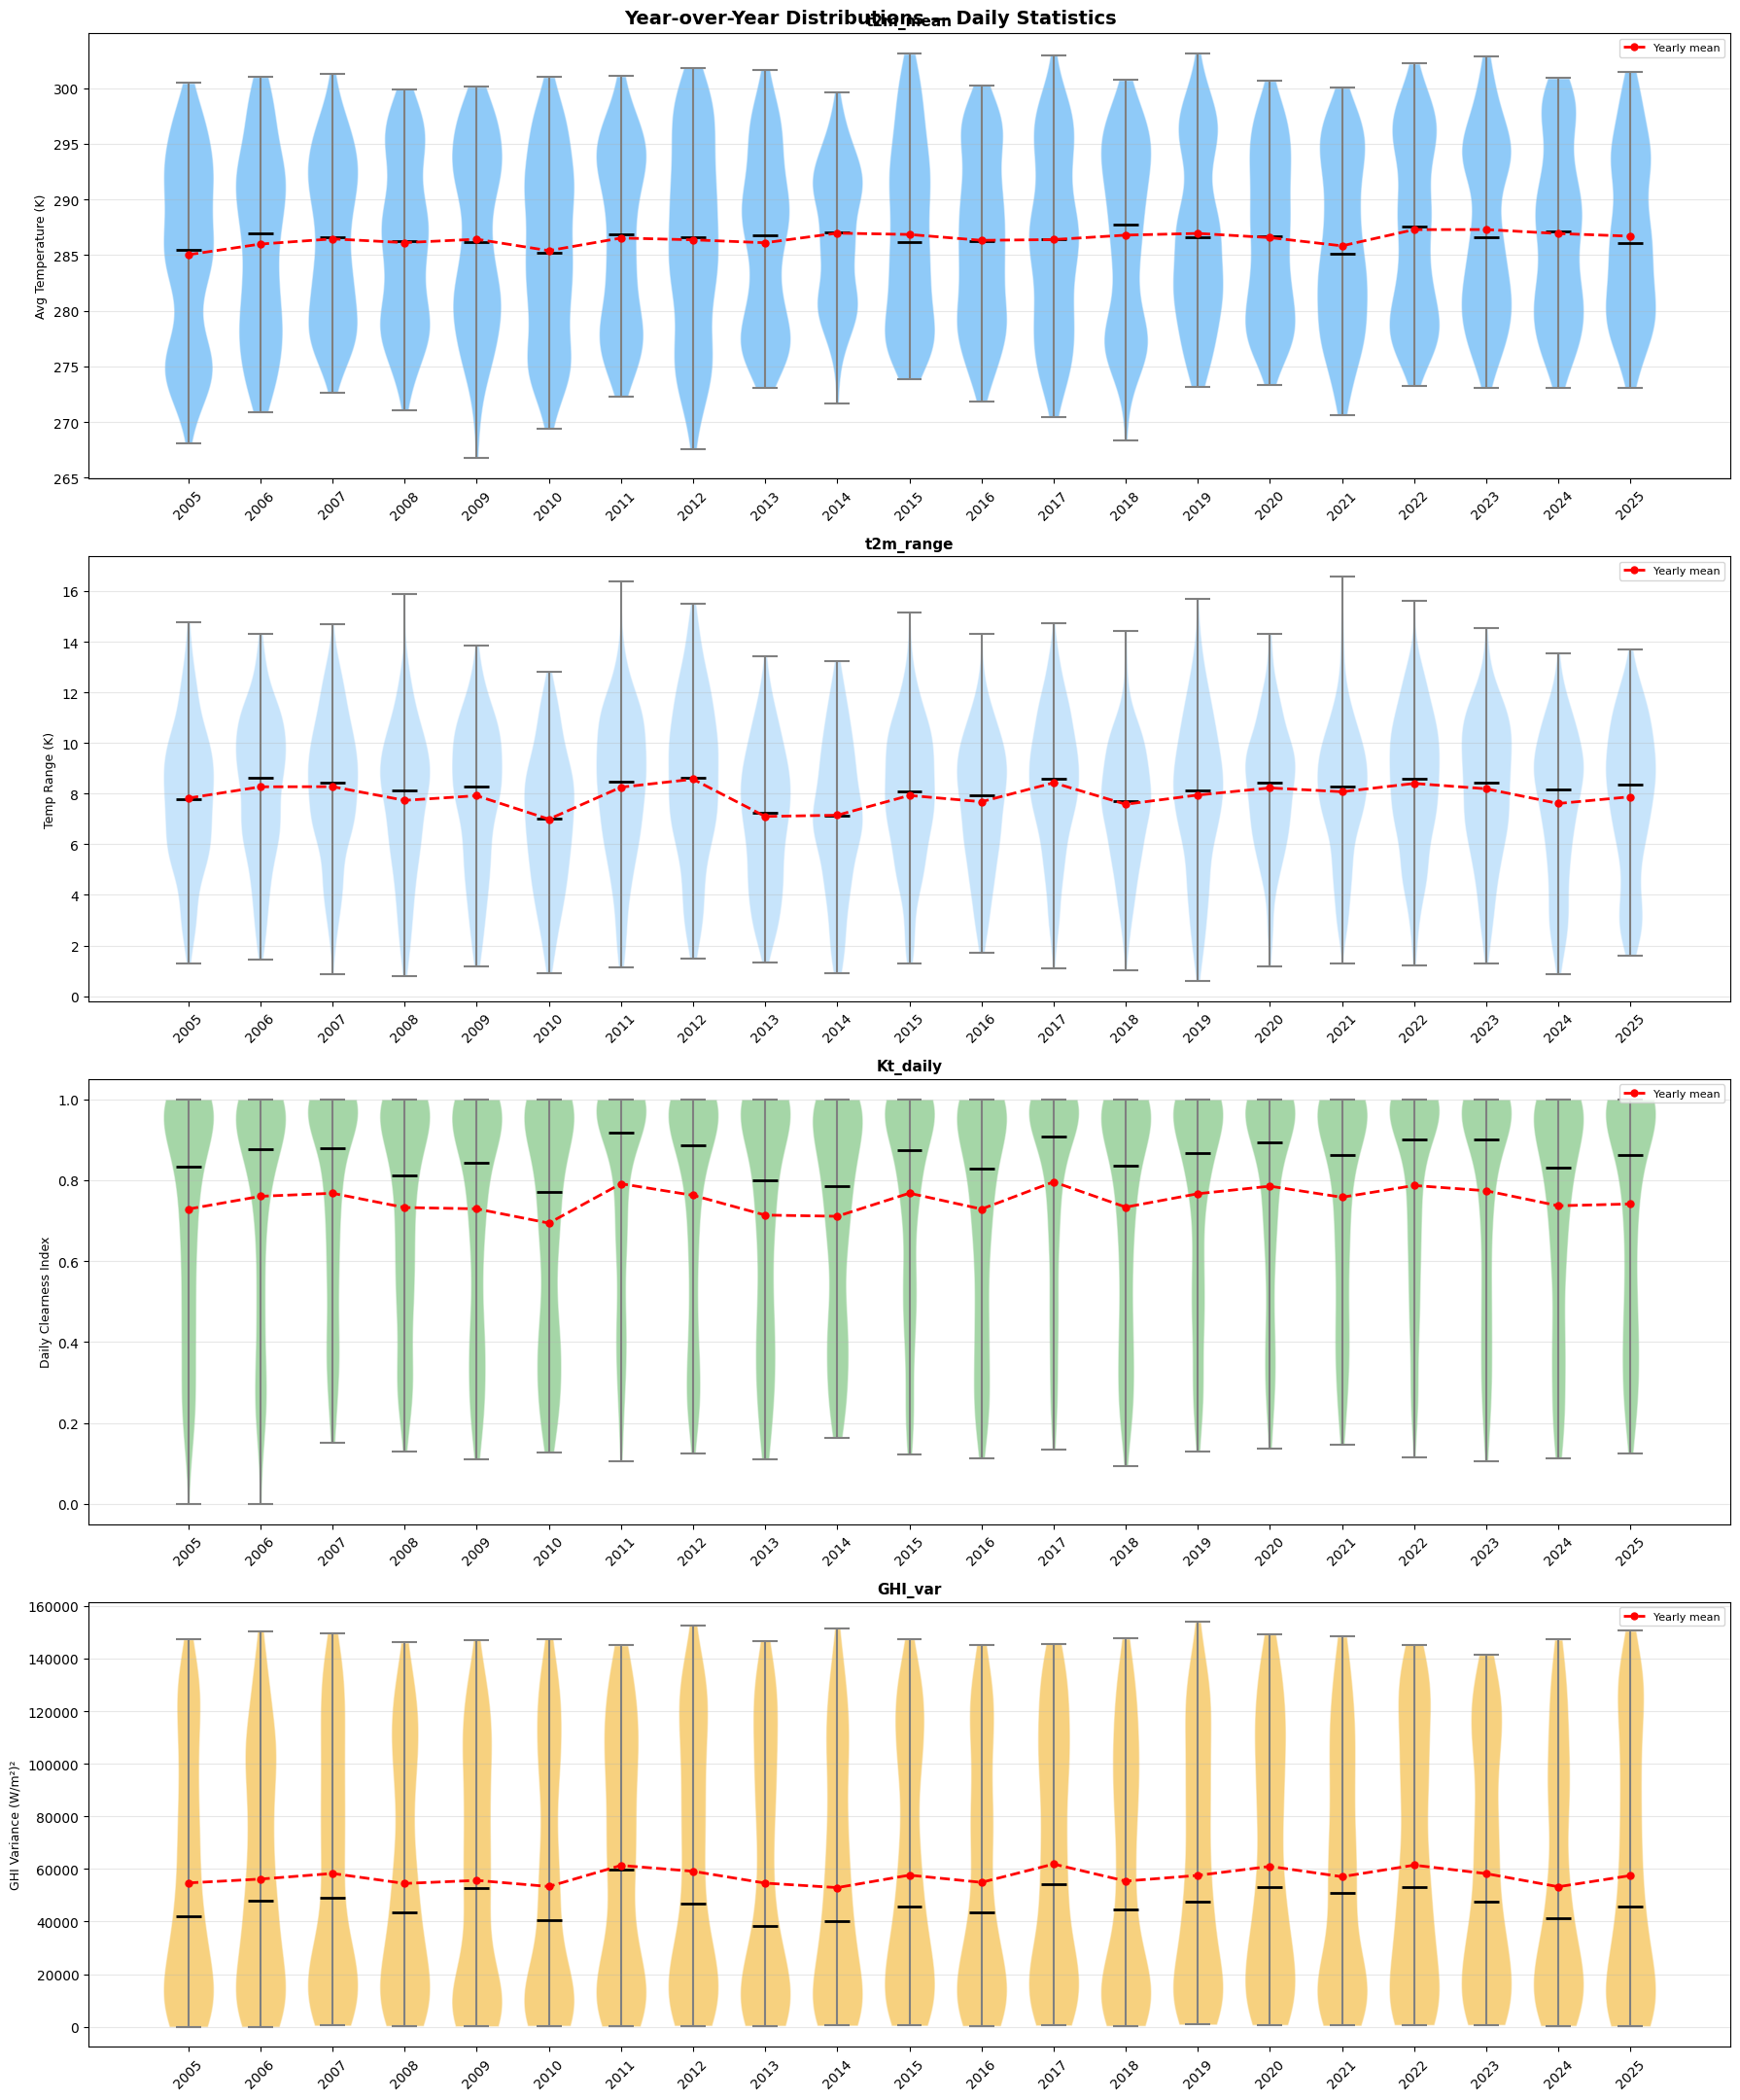

In [70]:
df_daily['year'] = pd.to_datetime(df_daily['date']).dt.year
years = sorted(df_daily['year'].unique())

variables = [
    {'col': 't2m_mean',  'label': 'Avg Temperature (K)',    'color': '#2196F3'},
    {'col': 't2m_range', 'label': 'Temp Range (K)',         'color': '#90CAF9'},
    {'col': 'Kt_daily',  'label': 'Daily Clearness Index',  'color': '#4CAF50'},
    {'col': 'GHI_var',   'label': 'GHI Variance (W/m²)²',  'color': '#f0a500'},
]

fig, axes = plt.subplots(4, 1, figsize=(18, 22))

for ax, var in zip(axes, variables):
    yearly_data = [
        df_daily.loc[df_daily['year'] == y, var['col']].dropna().values
        for y in years
    ]

    # Violin plot
    parts = ax.violinplot(yearly_data, positions=range(1, len(years) + 1),
                          showmedians=True, showextrema=True, widths=0.7)

    # Style violins
    for pc in parts['bodies']:
        pc.set_facecolor(var['color'])
        pc.set_alpha(0.5)
        pc.set_edgecolor('white')
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cmaxes'].set_color('grey')
    parts['cmins'].set_color('grey')
    parts['cbars'].set_color('grey')

    # Yearly mean overlay
    yearly_means = [arr.mean() if len(arr) > 0 else np.nan for arr in yearly_data]
    ax.plot(range(1, len(years) + 1), yearly_means, color='red', lw=2,
            marker='o', markersize=5, linestyle='--', label='Yearly mean')

    ax.set_title(var['col'], fontsize=11, fontweight='bold')
    ax.set_ylabel(var['label'], fontsize=9)
    ax.set_xticks(range(1, len(years) + 1))
    ax.set_xticklabels(years, rotation=45)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Year-over-Year Distributions — Daily Statistics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

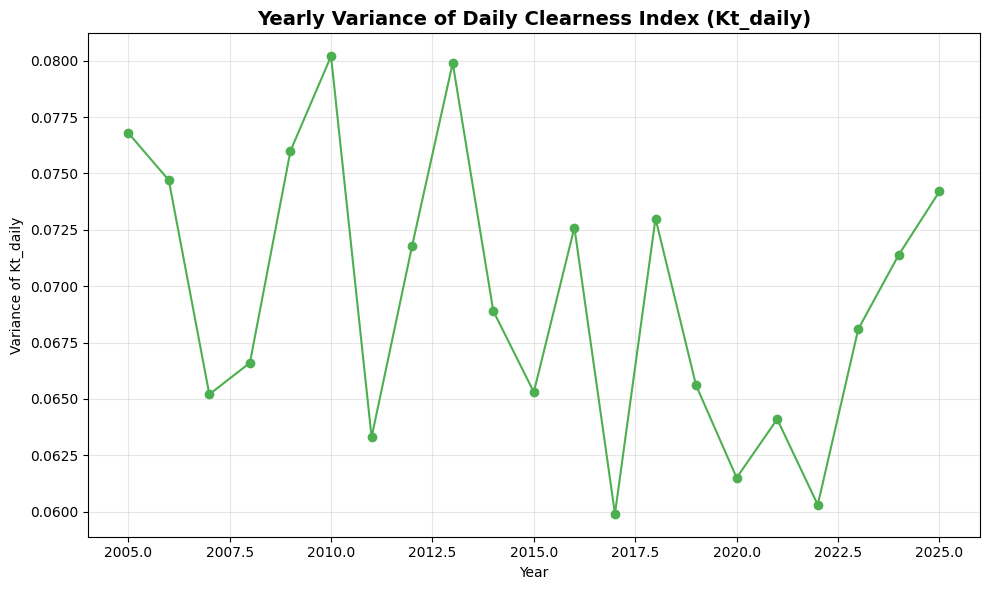

In [71]:
# Calculate the yearly variance of the daily clearness index (Kt_daily) to assess inter-annual variability and potential trends in atmospheric clarity over the years.
kt_yearly_var = (
    df_daily.groupby('year')['Kt_daily']
    .agg(
        count  = 'count',
        mean   = 'mean',
        median = 'median',
        std    = 'std',
        var    = 'var',
    )
    .round(4)
)

# Plot the yearly variance of Kt_daily to visualize inter-annual variability and identify any trends in atmospheric clarity over the years.
plt.figure(figsize=(10, 6))
plt.plot(kt_yearly_var.index, kt_yearly_var['var'], marker='o', color='#4CAF50', linestyle='-')
plt.title('Yearly Variance of Daily Clearness Index (Kt_daily)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Variance of Kt_daily')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [72]:
# Calculate the total GHI by year
ghi_yearly_sum = (
    df_daily.groupby('year')['GHI_sum']
    .agg(total_GHI='sum')
    .round(2)
)
print("=== YEARLY TOTAL GHI ===")
print(ghi_yearly_sum.to_string())

=== YEARLY TOTAL GHI ===
       total_GHI
year            
2005  1439415.19
2006  1476727.57
2007  1513248.36
2008  1452216.16
2009  1463609.19
2010  1411075.23
2011  1568844.23
2012  1526552.92
2013  1429789.21
2014  1416103.47
2015  1508457.07
2016  1452848.36
2017  1588139.29
2018  1453933.41
2019  1509550.74
2020  1572901.21
2021  1506617.39
2022  1572735.01
2023  1514177.19
2024  1442180.14
2025  1500623.81


=== HOT & COLD DAYS PER YEAR ===
  Hot  threshold : t2m_max > 303.15 K (30.0°C)
  Cold threshold : t2m_min < 273.15 K (0.0°C)

      total_days  hot_days  cold_days  hot_pct  cold_pct
year                                                    
2005         365         9         94     2.47     25.75
2006         365        25         65     6.85     17.81
2007         365        13         26     3.56      7.12
2008         366        15         38     4.10     10.38
2009         365        16         43     4.38     11.78
2010         365         5         61     1.37     16.71
2011         365        10         44     2.74     12.05
2012         366        40         65    10.93     17.76
2013         365        17         40     4.66     10.96
2014         365         3          8     0.82      2.19
2015         365        37         28    10.14      7.67
2016         366        13         38     3.55     10.38
2017         365        28         47     7.67     12.88
2018         365  

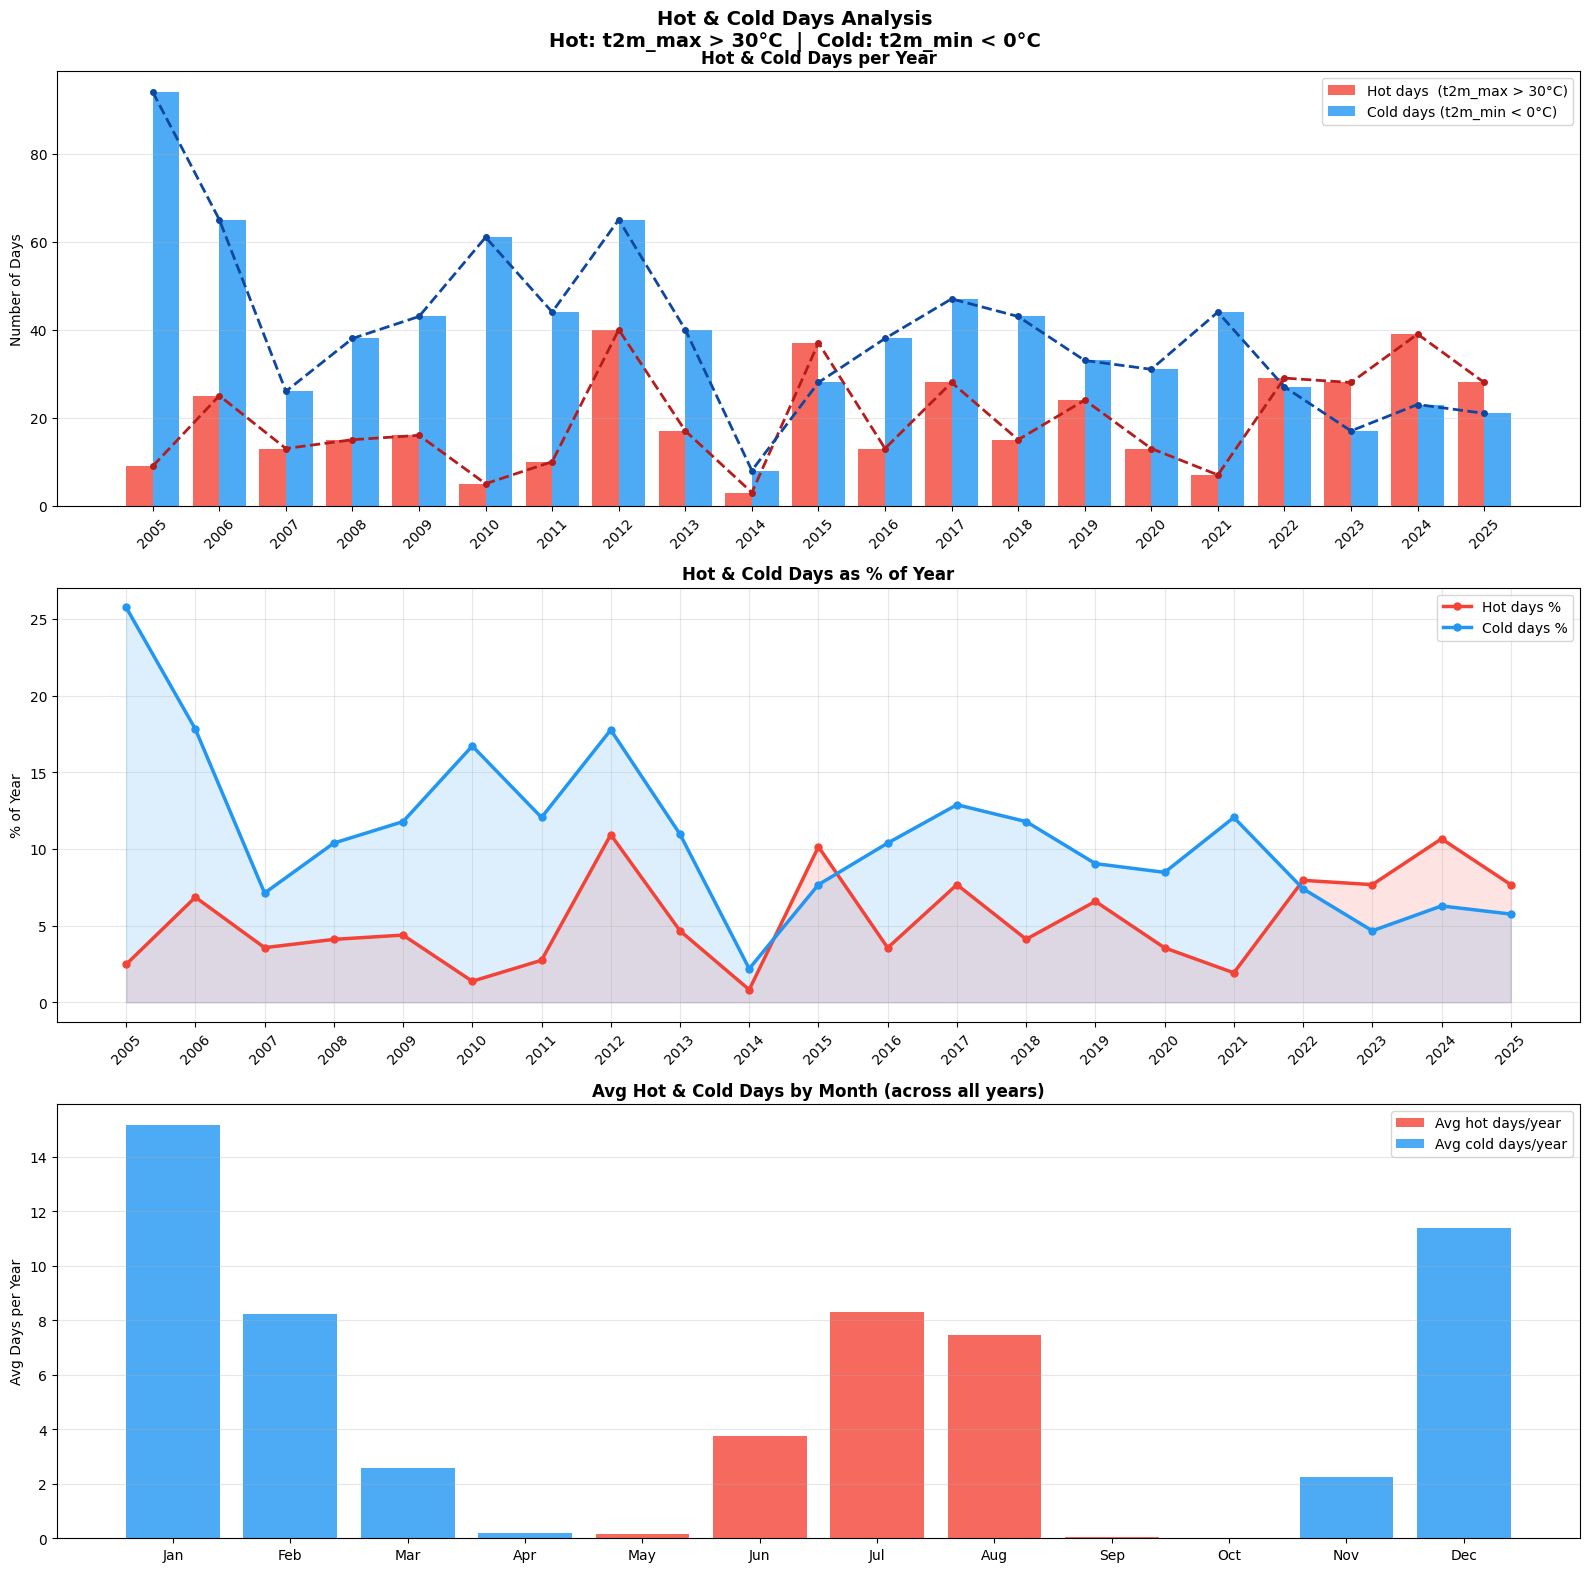

In [73]:
# --- Hot & Cold Days Analysis ---

# ── Thresholds ────────────────────────────────────────────────────────────────
HOT_THRESHOLD  = 303.15  # K = 30°C
COLD_THRESHOLD = 273.15  # K =  0°C

df_daily['year']     = pd.to_datetime(df_daily['date']).dt.year
df_daily['month']    = pd.to_datetime(df_daily['date']).dt.month
df_daily['is_hot']   = df_daily['t2m_max'] > HOT_THRESHOLD
df_daily['is_cold']  = df_daily['t2m_min'] < COLD_THRESHOLD

# ── 1. Annual counts ──────────────────────────────────────────────────────────
annual = (
    df_daily.groupby('year')
    .agg(
        total_days = ('date',     'count'),
        hot_days   = ('is_hot',   'sum'),
        cold_days  = ('is_cold',  'sum'),
    )
    .assign(
        hot_pct  = lambda x: (x['hot_days']  / x['total_days'] * 100).round(2),
        cold_pct = lambda x: (x['cold_days'] / x['total_days'] * 100).round(2),
    )
)

print("=== HOT & COLD DAYS PER YEAR ===")
print(f"  Hot  threshold : t2m_max > {HOT_THRESHOLD} K ({HOT_THRESHOLD - 273.15:.1f}°C)")
print(f"  Cold threshold : t2m_min < {COLD_THRESHOLD} K ({COLD_THRESHOLD - 273.15:.1f}°C)\n")
print(annual.to_string())

# ── 2. Monthly breakdown (averaged across all years) ─────────────────────────
monthly = (
    df_daily.groupby('month')
    .agg(hot_days=('is_hot', 'sum'), cold_days=('is_cold', 'sum'))
    .assign(
        hot_days_per_year  = lambda x: (x['hot_days']  / df_daily['year'].nunique()).round(2),
        cold_days_per_year = lambda x: (x['cold_days'] / df_daily['year'].nunique()).round(2),
    )
    .drop(columns=['hot_days', 'cold_days'])
)
monthly.index = month_labels

print("\n=== AVG HOT & COLD DAYS PER MONTH (across all years) ===")
print(monthly.to_string())

# ── 3. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# ── 3.1 Annual hot & cold days bar chart ──────────────────────────────────────
ax = axes[0]
x  = np.arange(len(annual))
w  = 0.4
ax.bar(x - w/2, annual['hot_days'],  width=w, color='#f44336', alpha=0.8, label=f'Hot days  (t2m_max > {HOT_THRESHOLD-273.15:.0f}°C)')
ax.bar(x + w/2, annual['cold_days'], width=w, color='#2196F3', alpha=0.8, label=f'Cold days (t2m_min < {COLD_THRESHOLD-273.15:.0f}°C)')

# Trend lines
ax.plot(x, annual['hot_days'],  color='#b71c1c', lw=2, linestyle='--', marker='o', markersize=4)
ax.plot(x, annual['cold_days'], color='#0d47a1', lw=2, linestyle='--', marker='o', markersize=4)

ax.set_xticks(x)
ax.set_xticklabels(annual.index, rotation=45)
ax.set_ylabel('Number of Days')
ax.set_title('Hot & Cold Days per Year', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# ── 3.2 % of year ─────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(annual.index, annual['hot_pct'],  color='#f44336', lw=2.5, marker='o', markersize=5, label='Hot days %')
ax.plot(annual.index, annual['cold_pct'], color='#2196F3', lw=2.5, marker='o', markersize=5, label='Cold days %')
ax.fill_between(annual.index, annual['hot_pct'],  alpha=0.15, color='#f44336')
ax.fill_between(annual.index, annual['cold_pct'], alpha=0.15, color='#2196F3')
ax.set_ylabel('% of Year')
ax.set_title('Hot & Cold Days as % of Year', fontsize=12, fontweight='bold')
ax.set_xticks(annual.index)
ax.set_xticklabels(annual.index, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3.3 Monthly breakdown stacked bar ────────────────────────────────────────
ax = axes[2]
x  = np.arange(1, 13)
ax.bar(x, monthly['hot_days_per_year'],  color='#f44336', alpha=0.8, label='Avg hot days/year')
ax.bar(x, monthly['cold_days_per_year'], color='#2196F3', alpha=0.8, label='Avg cold days/year')
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Avg Days per Year')
ax.set_title('Avg Hot & Cold Days by Month (across all years)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'Hot & Cold Days Analysis\nHot: t2m_max > {HOT_THRESHOLD-273.15:.0f}°C  |  Cold: t2m_min < {COLD_THRESHOLD-273.15:.0f}°C',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Clean up ──────────────────────────────────────────────────────────────────
df_daily = df_daily.drop(columns=['is_hot', 'is_cold'])

=== GHI VARIANCE — ANNUAL STATISTICS ===
           mean     median        std        q25         q75
year                                                        
2005  54689.917  41866.781  45091.300  14579.421   92924.782
2006  56157.729  47795.165  43044.963  16764.569   96872.047
2007  58287.743  48881.854  45931.054  16859.782   99063.455
2008  54479.138  43344.951  43873.154  15751.040   95046.309
2009  55648.193  52911.190  44593.759  11719.119   96409.392
2010  53327.414  40614.344  46634.569   9517.699   98600.241
2011  61345.598  59709.652  45417.036  16866.652  104520.645
2012  59125.001  46761.138  46324.695  16983.517  102259.993
2013  54615.707  38272.407  46737.622  11162.306   98888.742
2014  52907.401  40082.642  43935.714  12037.665   90938.759
2015  57648.360  45588.531  45237.690  17116.770  101702.959
2016  54897.559  43506.420  44918.467  14485.748   91391.658
2017  61874.237  54254.686  45764.895  19667.074  103640.937
2018  55381.979  44539.548  45176.909  13565

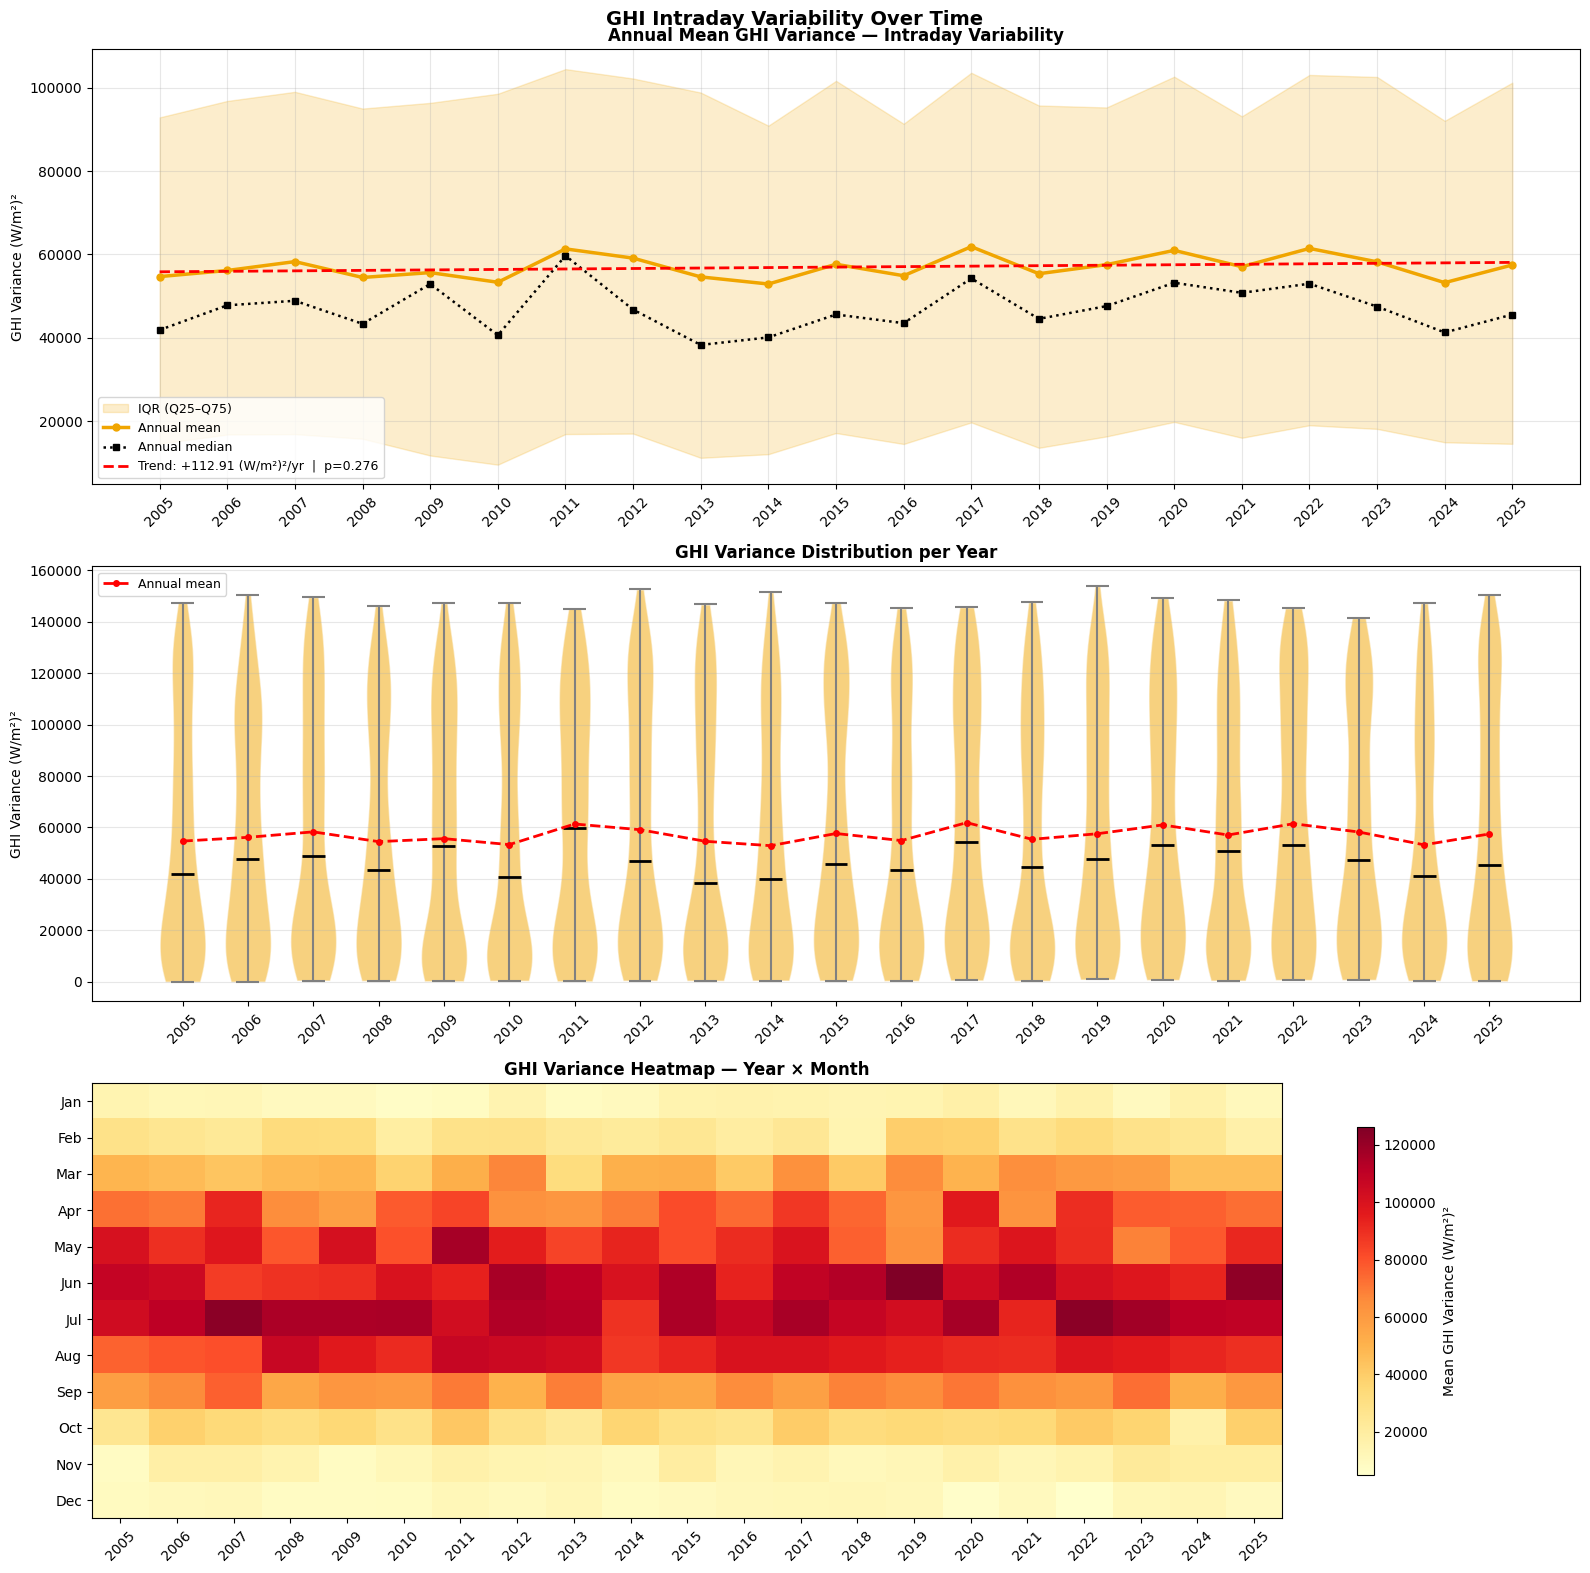

In [74]:
# --- GHI Variance Annual Mean — Intraday Variability Over Time ---

from scipy import stats

df_daily['year'] = pd.to_datetime(df_daily['date']).dt.year

# ── 1. Annual statistics ──────────────────────────────────────────────────────
annual_var = (
    df_daily.groupby('year')['GHI_var']
    .agg(
        mean   = 'mean',
        median = 'median',
        std    = 'std',
        q25    = lambda x: x.quantile(0.25),
        q75    = lambda x: x.quantile(0.75),
    )
    .round(3)
)

print("=== GHI VARIANCE — ANNUAL STATISTICS ===")
print(annual_var.to_string())

# ── 2. Linear trend ───────────────────────────────────────────────────────────
years  = annual_var.index.values
means  = annual_var['mean'].values
slope, intercept, r, p, se = stats.linregress(years, means)

print(f"\n=== LINEAR TREND ===")
print(f"  Slope     : {slope:.4f} (W/m²)²/year")
print(f"  R²        : {r**2:.4f}")
print(f"  p-value   : {p:.4f}  {'⚠️  Significant trend' if p < 0.05 else '✅  No significant trend'}")

# ── 3. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# ── 3.1 Annual mean + IQR band + trend line ───────────────────────────────────
ax = axes[0]
ax.fill_between(years, annual_var['q25'], annual_var['q75'],
                color='#f0a500', alpha=0.2, label='IQR (Q25–Q75)')
ax.plot(years, annual_var['mean'],   color='#f0a500', lw=2.5, marker='o',
        markersize=5, label='Annual mean')
ax.plot(years, annual_var['median'], color='black',   lw=1.8, linestyle=':',
        marker='s', markersize=4, label='Annual median')

# Trend line
trend = intercept + slope * years
ax.plot(years, trend, color='red', lw=2, linestyle='--',
        label=f'Trend: {slope:+.2f} (W/m²)²/yr  |  p={p:.3f}')

ax.set_ylabel('GHI Variance (W/m²)²')
ax.set_title('Annual Mean GHI Variance — Intraday Variability', fontsize=12, fontweight='bold')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 3.2 Violin per year ───────────────────────────────────────────────────────
ax = axes[1]
yearly_data = [df_daily.loc[df_daily['year'] == y, 'GHI_var'].dropna().values for y in years]

parts = ax.violinplot(yearly_data, positions=range(1, len(years) + 1),
                      showmedians=True, showextrema=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor('#f0a500')
    pc.set_alpha(0.5)
    pc.set_edgecolor('white')
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cmaxes'].set_color('grey')
parts['cmins'].set_color('grey')
parts['cbars'].set_color('grey')

ax.plot(range(1, len(years) + 1), means, color='red', lw=2,
        marker='o', markersize=4, linestyle='--', label='Annual mean')
ax.set_xticks(range(1, len(years) + 1))
ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('GHI Variance (W/m²)²')
ax.set_title('GHI Variance Distribution per Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── 3.3 Monthly breakdown per year (heatmap) ──────────────────────────────────
ax = axes[2]
df_daily['month'] = pd.to_datetime(df_daily['date']).dt.month
heatmap_data = (
    df_daily.groupby(['year', 'month'])['GHI_var']
    .mean()
    .unstack(level='month')
    .round(2)
)
heatmap_data.columns = month_labels

im = ax.imshow(heatmap_data.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_yticks(range(12))
ax.set_yticklabels(month_labels)
ax.set_title('GHI Variance Heatmap — Year × Month', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean GHI Variance (W/m²)²', shrink=0.8)

plt.suptitle('GHI Intraday Variability Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Kt DAILY — ANNUAL STATISTICS ===
        mean  median     std     q25     q75
year                                        
2005  0.7286  0.8324  0.2772  0.5176  0.9749
2006  0.7602  0.8775  0.2734  0.5993  0.9831
2007  0.7677  0.8799  0.2553  0.5866  0.9864
2008  0.7325  0.8129  0.2580  0.5260  0.9750
2009  0.7292  0.8441  0.2756  0.4920  0.9657
2010  0.6939  0.7704  0.2832  0.4192  0.9686
2011  0.7912  0.9164  0.2516  0.6471  0.9938
2012  0.7626  0.8863  0.2679  0.5853  0.9837
2013  0.7137  0.7999  0.2826  0.4628  0.9793
2014  0.7108  0.7848  0.2625  0.4708  0.9543
2015  0.7679  0.8735  0.2555  0.5839  0.9882
2016  0.7286  0.8291  0.2694  0.5138  0.9730
2017  0.7958  0.9086  0.2448  0.6614  0.9891
2018  0.7334  0.8363  0.2701  0.5147  0.9720
2019  0.7665  0.8682  0.2562  0.5616  0.9842
2020  0.7852  0.8922  0.2480  0.6482  0.9911
2021  0.7578  0.8630  0.2533  0.5741  0.9836
2022  0.7869  0.8998  0.2456  0.6257  0.9922
2023  0.7739  0.9003  0.2609  0.6065  0.9902
2024  0.7367  0.83

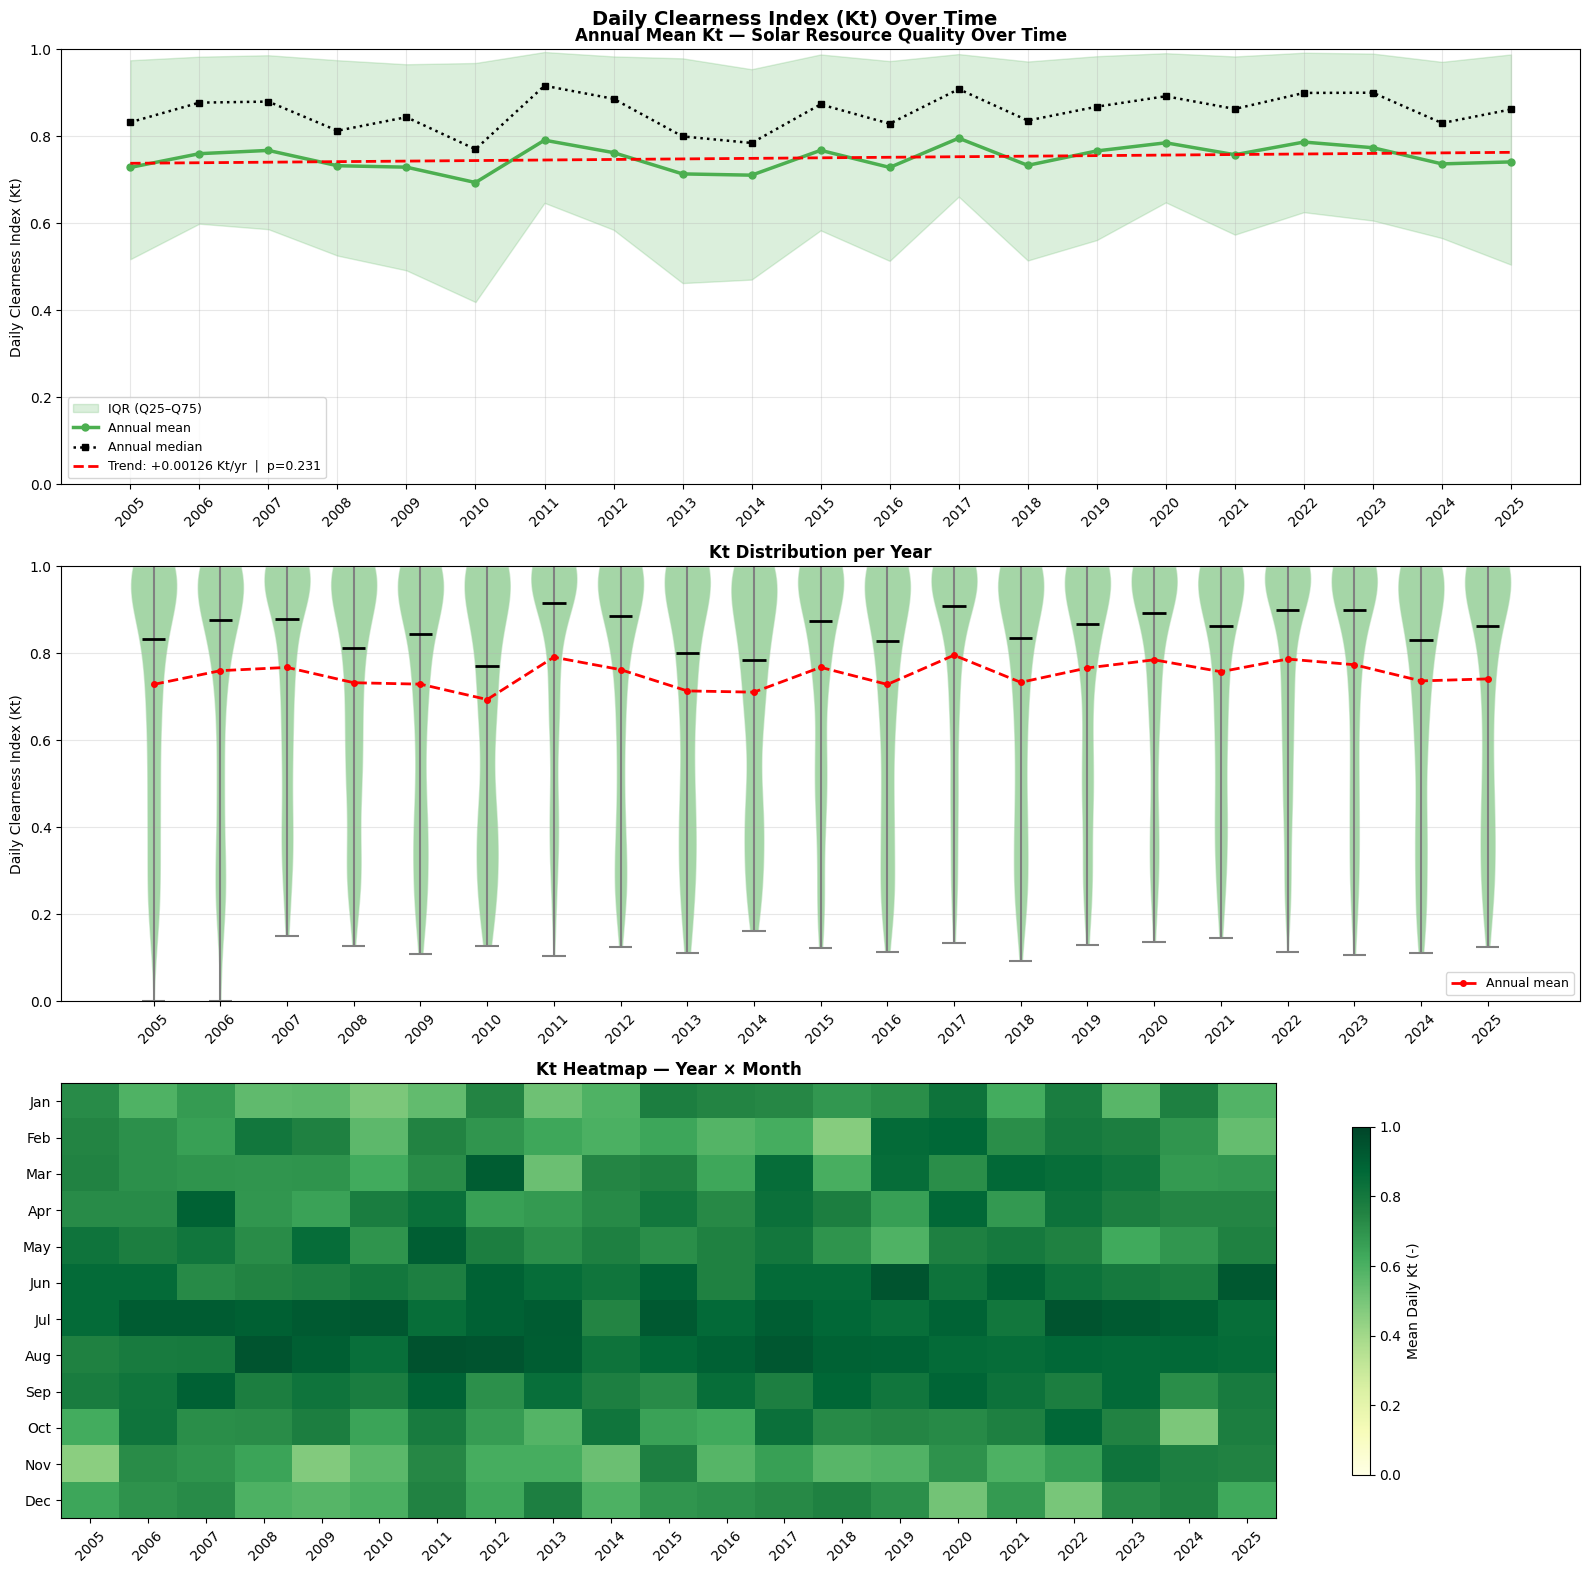

In [75]:
# --- Kt Annual Mean — Variability Over Time ---

from scipy import stats

df_daily['year'] = pd.to_datetime(df_daily['date']).dt.year

# ── 1. Annual statistics ──────────────────────────────────────────────────────
annual_kt = (
    df_daily.groupby('year')['Kt_daily']
    .agg(
        mean   = 'mean',
        median = 'median',
        std    = 'std',
        q25    = lambda x: x.quantile(0.25),
        q75    = lambda x: x.quantile(0.75),
    )
    .round(4)
)

print("=== Kt DAILY — ANNUAL STATISTICS ===")
print(annual_kt.to_string())

# ── 2. Linear trend ───────────────────────────────────────────────────────────
years     = annual_kt.index.values
means     = annual_kt['mean'].values
slope, intercept, r, p, se = stats.linregress(years, means)

print(f"\n=== LINEAR TREND ===")
print(f"  Slope     : {slope:.6f} Kt/year")
print(f"  R²        : {r**2:.4f}")
print(f"  p-value   : {p:.4f}  {'⚠️  Significant trend' if p < 0.05 else '✅  No significant trend'}")

# ── 3. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# ── 3.1 Annual mean + IQR band + trend line ───────────────────────────────────
ax = axes[0]
ax.fill_between(years, annual_kt['q25'], annual_kt['q75'],
                color='#4CAF50', alpha=0.2, label='IQR (Q25–Q75)')
ax.plot(years, annual_kt['mean'],   color='#4CAF50', lw=2.5, marker='o',
        markersize=5, label='Annual mean')
ax.plot(years, annual_kt['median'], color='black',   lw=1.8, linestyle=':',
        marker='s', markersize=4, label='Annual median')

# Trend line
trend = intercept + slope * years
ax.plot(years, trend, color='red', lw=2, linestyle='--',
        label=f'Trend: {slope:+.5f} Kt/yr  |  p={p:.3f}')

ax.set_ylabel('Daily Clearness Index (Kt)')
ax.set_title('Annual Mean Kt — Solar Resource Quality Over Time', fontsize=12, fontweight='bold')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 3.2 Violin per year ───────────────────────────────────────────────────────
ax = axes[1]
yearly_data = [df_daily.loc[df_daily['year'] == y, 'Kt_daily'].dropna().values for y in years]

parts = ax.violinplot(yearly_data, positions=range(1, len(years) + 1),
                      showmedians=True, showextrema=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor('#4CAF50')
    pc.set_alpha(0.5)
    pc.set_edgecolor('white')
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cmaxes'].set_color('grey')
parts['cmins'].set_color('grey')
parts['cbars'].set_color('grey')

ax.plot(range(1, len(years) + 1), means, color='red', lw=2,
        marker='o', markersize=4, linestyle='--', label='Annual mean')
ax.set_xticks(range(1, len(years) + 1))
ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('Daily Clearness Index (Kt)')
ax.set_ylim(0, 1)
ax.set_title('Kt Distribution per Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── 3.3 Monthly breakdown per year (heatmap) ──────────────────────────────────
ax = axes[2]
df_daily['month'] = pd.to_datetime(df_daily['date']).dt.month
heatmap_data = (
    df_daily.groupby(['year', 'month'])['Kt_daily']
    .mean()
    .unstack(level='month')
    .round(4)
)
heatmap_data.columns = month_labels

im = ax.imshow(heatmap_data.T, aspect='auto', cmap='YlGn',
               interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_yticks(range(12))
ax.set_yticklabels(month_labels)
ax.set_title('Kt Heatmap — Year × Month', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean Daily Kt (-)', shrink=0.8)

plt.suptitle('Daily Clearness Index (Kt) Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== t2m_mean — ANNUAL STATISTICS ===
            mean      median     std       q25       q75
year                                                    
2005  285.041901  285.499298  8.3119  276.2453  292.1337
2006  285.995300  286.996490  8.1819  278.4939  292.3582
2007  286.459808  286.635101  7.2377  279.9810  292.6745
2008  286.124603  286.292786  7.5220  279.1557  293.0107
2009  286.430298  286.206085  8.0923  279.9715  293.3667
2010  285.403015  285.224792  8.0432  278.8802  291.9977
2011  286.540802  286.898804  7.8650  278.7647  293.4718
2012  286.376099  286.569305  8.7747  279.1021  293.8269
2013  286.112701  286.773193  7.7090  278.4769  292.2230
2014  286.979004  287.006012  6.1793  281.3198  291.8273
2015  286.858002  286.154694  8.0024  279.6238  293.0915
2016  286.329895  286.262512  7.5364  279.4667  292.7437
2017  286.398010  286.454010  8.0969  279.5016  293.3503
2018  286.799591  287.738098  8.1529  278.4054  294.2177
2019  286.952911  286.618591  7.6124  280.9987  294

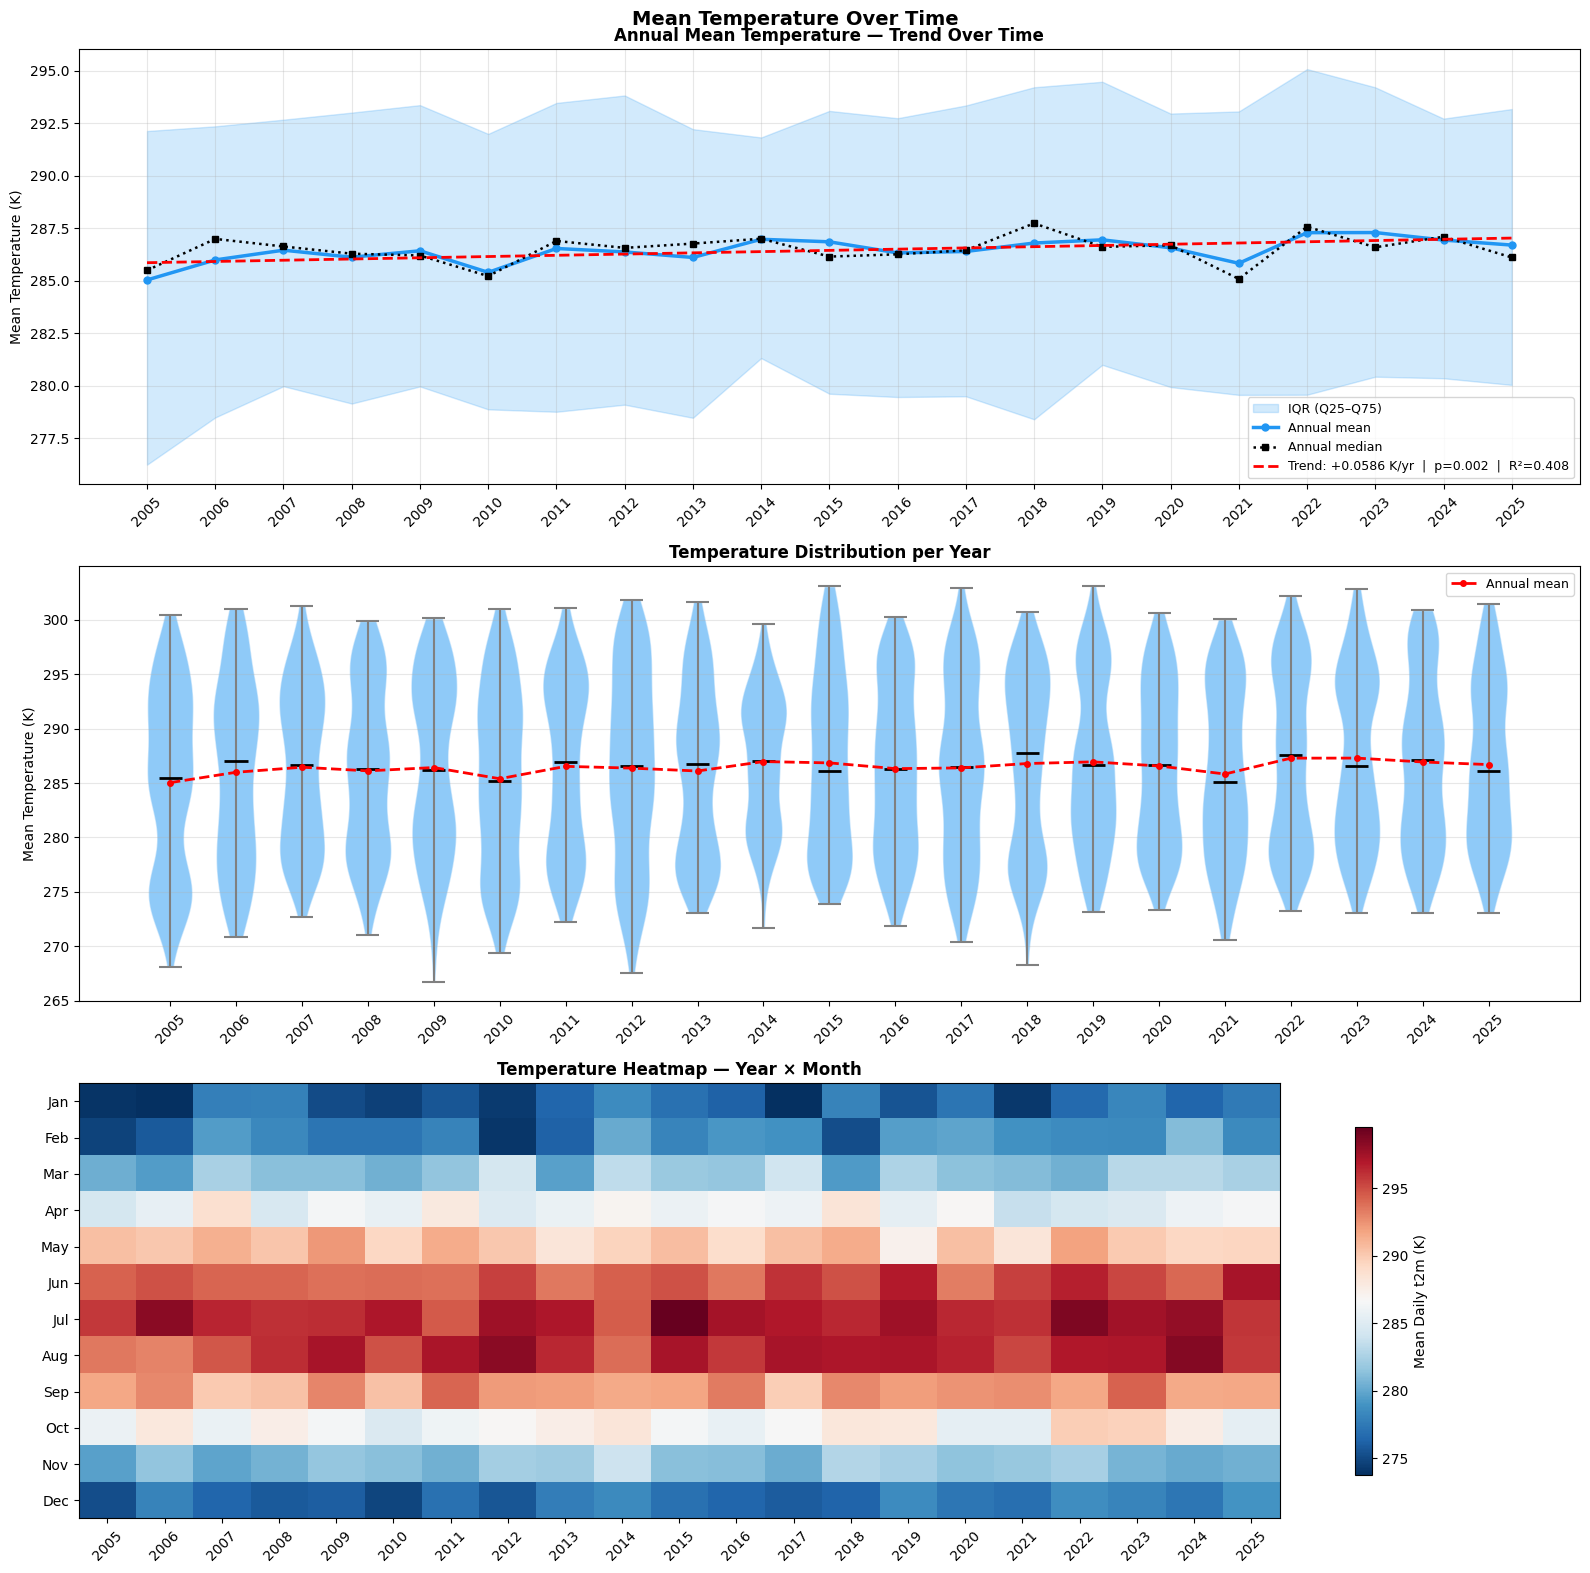

In [76]:
# --- Temperature Annual Mean — Variability Over Time ---

from scipy import stats

df_daily['year'] = pd.to_datetime(df_daily['date']).dt.year

# ── 1. Annual statistics ──────────────────────────────────────────────────────
annual_t2m = (
    df_daily.groupby('year')['t2m_mean']
    .agg(
        mean   = 'mean',
        median = 'median',
        std    = 'std',
        q25    = lambda x: x.quantile(0.25),
        q75    = lambda x: x.quantile(0.75),
    )
    .round(4)
)

print("=== t2m_mean — ANNUAL STATISTICS ===")
print(annual_t2m.to_string())

# ── 2. Linear trend ───────────────────────────────────────────────────────────
years     = annual_t2m.index.values
means     = annual_t2m['mean'].values
slope, intercept, r, p, se = stats.linregress(years, means)

print(f"\n=== LINEAR TREND ===")
print(f"  Slope     : {slope:.4f} K/year")
print(f"  Total     : {slope * (years[-1] - years[0]):.4f} K over {years[-1] - years[0]} years")
print(f"  R²        : {r**2:.4f}")
print(f"  p-value   : {p:.4f}  {'⚠️  Significant trend' if p < 0.05 else '✅  No significant trend'}")

# ── 3. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# ── 3.1 Annual mean + IQR band + trend line ───────────────────────────────────
ax = axes[0]
ax.fill_between(years, annual_t2m['q25'], annual_t2m['q75'],
                color='#2196F3', alpha=0.2, label='IQR (Q25–Q75)')
ax.plot(years, annual_t2m['mean'],   color='#2196F3', lw=2.5, marker='o',
        markersize=5, label='Annual mean')
ax.plot(years, annual_t2m['median'], color='black',   lw=1.8, linestyle=':',
        marker='s', markersize=4, label='Annual median')

# Trend line
trend = intercept + slope * years
ax.plot(years, trend, color='red', lw=2, linestyle='--',
        label=f'Trend: {slope:+.4f} K/yr  |  p={p:.3f}  |  R²={r**2:.3f}')

ax.set_ylabel('Mean Temperature (K)')
ax.set_title('Annual Mean Temperature — Trend Over Time', fontsize=12, fontweight='bold')
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 3.2 Violin per year ───────────────────────────────────────────────────────
ax = axes[1]
yearly_data = [df_daily.loc[df_daily['year'] == y, 't2m_mean'].dropna().values for y in years]

parts = ax.violinplot(yearly_data, positions=range(1, len(years) + 1),
                      showmedians=True, showextrema=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_facecolor('#2196F3')
    pc.set_alpha(0.5)
    pc.set_edgecolor('white')
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cmaxes'].set_color('grey')
parts['cmins'].set_color('grey')
parts['cbars'].set_color('grey')

ax.plot(range(1, len(years) + 1), means, color='red', lw=2,
        marker='o', markersize=4, linestyle='--', label='Annual mean')
ax.set_xticks(range(1, len(years) + 1))
ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('Mean Temperature (K)')
ax.set_title('Temperature Distribution per Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ── 3.3 Monthly breakdown per year (heatmap) ──────────────────────────────────
ax = axes[2]
df_daily['month'] = pd.to_datetime(df_daily['date']).dt.month
heatmap_data = (
    df_daily.groupby(['year', 'month'])['t2m_mean']
    .mean()
    .unstack(level='month')
    .round(4)
)
heatmap_data.columns = month_labels

im = ax.imshow(heatmap_data.T, aspect='auto', cmap='RdBu_r',
               interpolation='nearest')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45)
ax.set_yticks(range(12))
ax.set_yticklabels(month_labels)
ax.set_title('Temperature Heatmap — Year × Month', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean Daily t2m (K)', shrink=0.8)

plt.suptitle('Mean Temperature Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

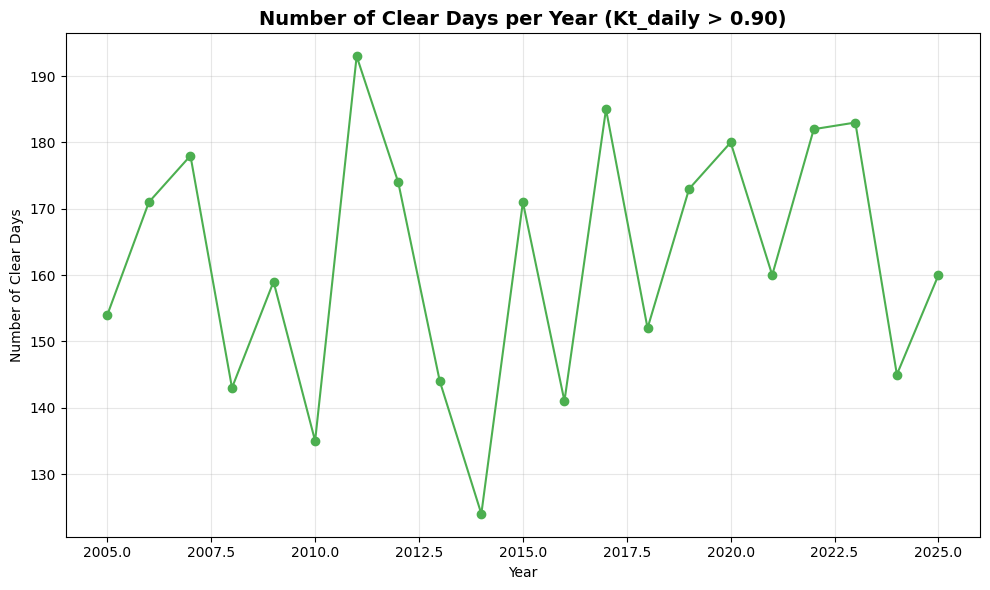

In [78]:
# Create a column 'clear_day' if the daily clearness index (Kt_daily) is greater than 0.90, indicating a clear day with good solar resource quality
df_daily['clear_day'] = df_daily['Kt_daily'] > 0.90
# Calculate the total number of clear days per year
clear_days_yearly = (
    df_daily.groupby('year')['clear_day']
    .sum()
    .rename('clear_days')
)

#Plot the number of clear days per year to visualize trends in solar resource quality over time
plt.figure(figsize=(10, 6))
plt.plot(clear_days_yearly.index, clear_days_yearly.values, marker='o', color='#4CAF50', linestyle='-')
plt.title('Number of Clear Days per Year (Kt_daily > 0.90)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Clear Days')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



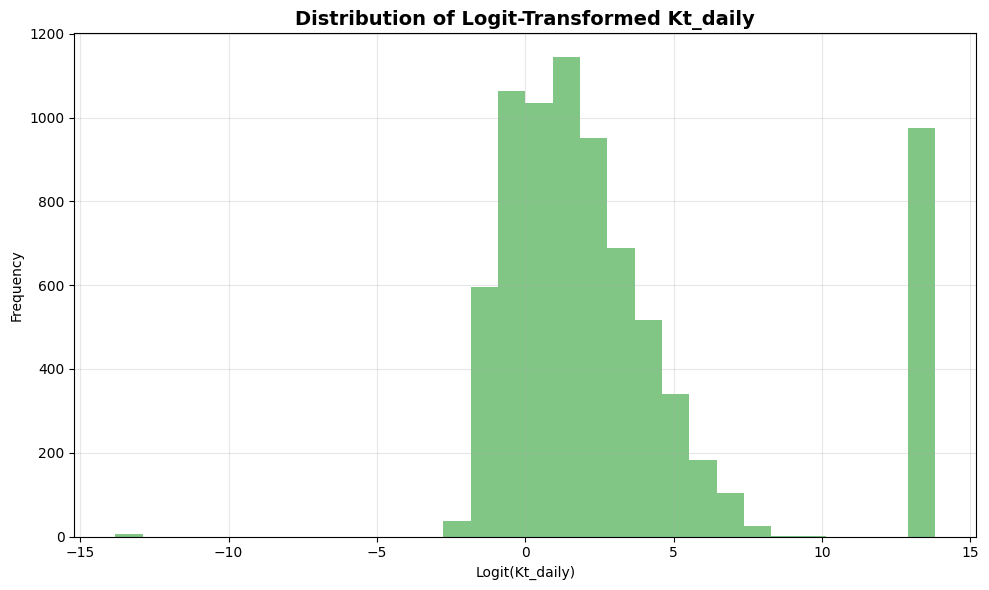

In [79]:
# Apply the logit transformation to the daily clearness index (Kt_daily) to better visualize trends in solar resource quality over time, especially if Kt values are close to 0 or 1
from scipy.special import logit
df_daily['Kt_logit'] = logit(df_daily['Kt_daily'].clip(1e-6, 1 - 1e-6))

# Show the distribution of the logit-transformed Kt values to check for normality and identify any outliers
plt.figure(figsize=(10, 6))
plt.hist(df_daily['Kt_logit'], bins=30, color='#4CAF50', alpha=0.7)
plt.title('Distribution of Logit-Transformed Kt_daily', fontsize=14, fontweight='bold')
plt.xlabel('Logit(Kt_daily)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

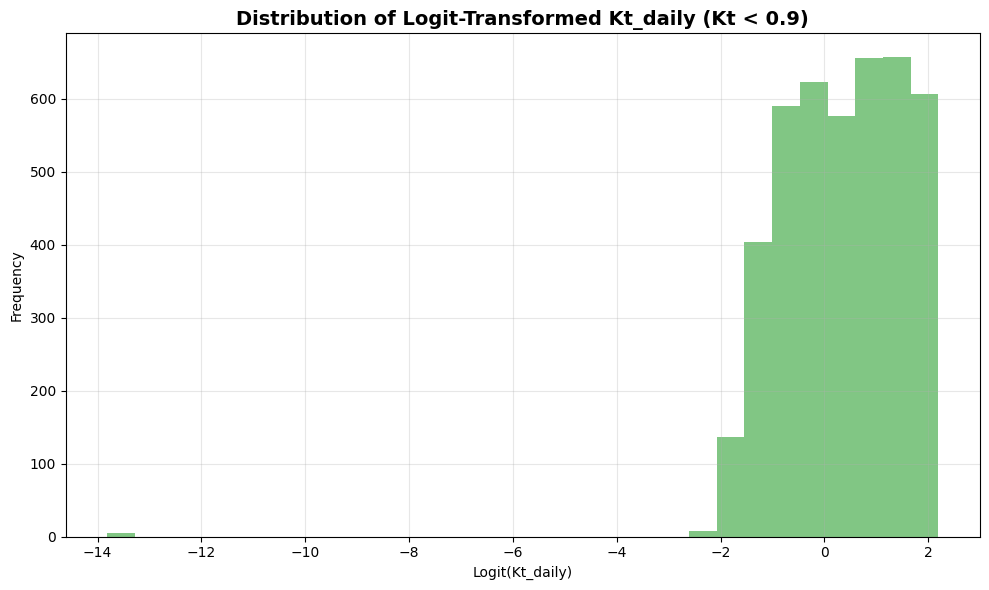

In [80]:
# Plot the distribuiton of the logit-transformed kt vlaues if kt is less than 0.9 to focus on lower clearness index values and better visualize trends in solar resource quality over time
plt.figure(figsize=(10, 6))
plt.hist(df_daily.loc[df_daily['Kt_daily'] < 0.9, 'Kt_logit'], bins=30, color='#4CAF50', alpha=0.7)
plt.title('Distribution of Logit-Transformed Kt_daily (Kt < 0.9)', fontsize=14, fontweight='bold')
plt.xlabel('Logit(Kt_daily)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()